# step1_phantom_video_analysis — Spiracle imaging + flight-mechanics pipeline (Step 1)

**What this notebook does.** Starting from one NIDAQ `.mat` recording (20 kHz sampling) plus its companion camera files, it turns raw camera trigger signals into a single time-aligned table of spiracle opening and flight variables. It runs as an ordered sequence of blocks:

- **Block 1** — diagnostic view of the Phantom high-speed-camera TTL (`Data[5,:]`).
- **Block 2** — detect Phantom triggers, end-anchor them to the per-frame intensity values in `*_PhantomCamera.xlsx`, and write `*_phantom_trigger_timedstamp.csv` (time, wingbeat frequency, normalized intensity, raw_B/raw_D).
- **Block 2.5** — flag and NaN-out frames where a wing/leg occludes the spiracle, using the rolling-median deviation of raw_B/raw_D.
- **Block 3** — rescale `normalized_intensity` to ~0–1 (`rescaled_intensity`) and write it back.
- **Block 4** — diagnostic view of the Basler camera TTL (`Data[8,:]`).
- **Block 5** — detect Basler triggers and join TopCamera wing tracking to produce `wingbeat_amplitude` → `*_basler_trigger_timestamp.csv`.
- **Block 6** — merge the Phantom and Basler CSVs onto a common 20 kHz grid, compute `inferred_flight_power`, add a reference `stimulus_sine`, and save `*_combined.csv`.

## Expected input files

All inputs live in the same folder and share the `.mat` basename — `<stem>` = the `.mat` path with its extension removed. Only `MAT_FILE` is set by hand (Block 1); the other two paths are derived from it automatically.

1. **`<stem>.mat`** — the NIDAQ recording, loaded with `scipy.io.loadmat(squeeze_me=True, struct_as_record=False)`. Must contain:
   - **`Data`** — float array, shape (9, n_samples) at 20 kHz (auto-transposed if stored as (n_samples, 9)); rows are `[time, AI0…AI7]` as in the channel table below.
   - **`phantom`** — a struct with **`rec_on_time_s`** and **`rec_off_time_s`** (floats, seconds) marking the Phantom recording window.

2. **`<stem>_PhantomCamera.xlsx`** — per-frame Phantom spiracle intensity, one row per saved Phantom frame. Read from the active sheet with `openpyxl`:
   - **Column E** — `normalized_intensity` (= B/D). **Row 1 is expected to be empty**; data starts at **row 2** and is read down until the first empty cell — that count is **M**, the number of Phantom frames used for end-anchored alignment.
   - **Column B** (`raw_B`) and **Column D** (`raw_D`) — the raw intensities behind E, used by the Block 2.5 occlusion filter. Columns A and C are ignored.

3. **`<stem>_TopCamera.csv`** — TopCamera wing tracking, one row per Top/Basler frame, read with `pandas.read_csv`. Must contain:
   - a **frame** column — preferentially named `Frame`, else the first column whose name contains "frame", else the first column;
   - a **left-wing** column (name contains both "left" and "wing") and a **right-wing** column (contains "right" and "wing"). Block 5 computes `wingbeat_amplitude = LeftWing + RightWing + 3.1416` and matches it to Basler edges by global frame number.

> Filenames must match the `<stem>_PhantomCamera.xlsx` / `<stem>_TopCamera.csv` convention exactly (Block 5 falls back to a `<stem>*_TopCamera*.csv` glob but errors if it finds more than one match).

## Expected output files

Written next to the `.mat`, sharing `<stem>`. The three CSVs are the pipeline products; figures are optional (Save buttons / auto-save).

**`<stem>_phantom_trigger_timedstamp.csv`** — written by Block 2, then updated in place by Blocks 2.5 and 3. After a full run its columns are:

| Column | Meaning |
|--------|---------|
| `frame_number` | End-anchored Phantom frame index, 1…M |
| `time` | Absolute NIDAQ time of the trigger (s) |
| `wingbeat_frequency` | Wingbeat frequency at the trigger (Hz; 100 × `Data[3]`) |
| `normalized_intensity` | Per-frame spiracle intensity (xlsx col E = B/D); set to NaN on occlusion frames by Block 2.5 |
| `raw_B`, `raw_D` | Raw intensities from xlsx cols B / D |
| `occlusion_outlier` | Added by Block 2.5: 1 = flagged as wing/leg occlusion, else 0 |
| `rescaled_intensity` | Added by Block 3: `normalized_intensity` rescaled to ~0–1 (1st/99th percentile) |

(Block 2 writes M rows; Block 3 rewrites the file keeping only rows with valid `time` and `normalized_intensity`, sorted by time, so occluded / NaN rows are dropped.)

**`<stem>_basler_trigger_timestamp.csv`** — written by Block 5:

| Column | Meaning |
|--------|---------|
| `frame_number_basler` | Global Basler frame index (k-th rising edge in the full recording), restricted to rec_on–rec_off |
| `time` | Absolute NIDAQ time of the Basler edge (s) |
| `wingbeat_amplitude` | `LeftWing + RightWing + 3.1416` (NaN if no matching TopCamera frame) |

**`<stem>_combined.csv`** — written by Block 6 on a uniform 20 kHz grid:

| Column | Meaning |
|--------|---------|
| `time_s` | Absolute NIDAQ time (s), uniform 20 kHz grid |
| `rescaled_intensity` | Phantom rescaled intensity, linearly interpolated to the grid (NaN outside coverage; all-NaN if Block 3 was skipped) |
| `wingbeat_amplitude` | Basler amplitude, interpolated to the grid |
| `wingbeat_frequency` | Phantom WBF (Hz), interpolated to the grid |
| `inferred_flight_power` | `C_PRO·Φ³·n³ + C_IND·Φ^(−0.5)` (Φ = amplitude, n = frequency; NaN where either is missing or ≤ 0) |
| `stimulus_sine` | Reference sine, 20 s period, range [-1, 1]; 0 at t = 60 s, +1 (peak) at t = 65 s |

**Optional figures** (same folder, `<stem>` prefix): the Save buttons in Blocks 1 / 2 / 5 emit `*_phantom_ttl_*.png` / `*_phantom_triggers_*.png` / `*_basler_triggers_*.png`; Block 3 emits `*_rescaled_*.svg`; Block 6 auto-saves `<stem>_combined.svg` + `.png` (its Save button also writes `*_<t0>s_<t1>s.svg/.png`). Block 4's Save writes `basler_trigger_*.png` to the current working directory.

## NIDAQ `Data` array layout

The `.mat` `Data` array has shape ≈ (9, n_samples); row 0 is time and rows 1–8 are analog-input channels AI0–AI7 (Python 0-indexed):

| Row | AI | Signal |
|-----|-----|--------|
| `Data[0]` | — | NIDAQ absolute time (s) — the shared time axis |
| `Data[1]` | AI0 | Wingbeat amplitude, left (WBA left) |
| `Data[2]` | AI1 | Wingbeat amplitude, right (WBA right) |
| `Data[3]` | AI2 | Wingbeat frequency (raw; ×100 → Hz) |
| `Data[4]` | AI3 | Arena X position (visual-stim ground truth) |
| `Data[5]` | AI4 | **Patchable BNC** — EMG *or* Hutchen trigger *or* Phantom sync. Step 1 treats it as the Phantom TTL, which only holds when AI4 is wired to Phantom sync. |
| `Data[6]` | AI5 | Opto TTL — LED driver input (AO1 hardware splitback) |
| `Data[7]` | AI6 | Right Hutchens |
| `Data[8]` | AI7 | Basler camera trigger (ctr0 splitback) |

> This notebook uses only `Data[0]` (time), `Data[3]` (WBF), `Data[5]` (Phantom TTL), and `Data[8]` (Basler TTL). The `Data[5]` = Phantom assignment depends on how AI4 was patched for that recording — see `PIPELINE.md`.

**Run order**: execute the blocks top to bottom; set `MAT_FILE` in Block 1 first (Blocks 4–6 reuse what earlier blocks load and save).

---

# step1_phantom_video_analysis — 气门成像 + 飞行力学分析流程（第 1 步）

**本笔记本的作用。** 从一份 NIDAQ `.mat` 记录（20 kHz 采样）及其配套相机文件出发，把原始相机触发信号转化为一张时间对齐的气门开度与飞行变量表。按固定顺序分块运行：

- **Block 1** — Phantom 高速相机 TTL（`Data[5,:]`）诊断视图。
- **Block 2** — 检测 Phantom 触发，按 `*_PhantomCamera.xlsx` 的逐帧强度做尾端对齐，写出 `*_phantom_trigger_timedstamp.csv`（时间、翼拍频率、归一化强度、raw_B/raw_D）。
- **Block 2.5** — 用 raw_B/raw_D 的滚动中位数偏差识别翅/腿遮挡帧并将其置为 NaN。
- **Block 3** — 将 `normalized_intensity` 重缩放到约 0–1（`rescaled_intensity`）并写回。
- **Block 4** — Basler 相机 TTL（`Data[8,:]`）诊断视图。
- **Block 5** — 检测 Basler 触发并联接 TopCamera 翼追踪，生成 `wingbeat_amplitude` → `*_basler_trigger_timestamp.csv`。
- **Block 6** — 将 Phantom 与 Basler 两表合并到统一 20 kHz 网格，计算 `inferred_flight_power`，加入参考 `stimulus_sine`，保存 `*_combined.csv`。

## 期望的输入文件

所有输入文件位于同一文件夹，且与 `.mat` 同名主干 —— `<stem>` 指去掉扩展名的 `.mat` 路径。只有 `MAT_FILE` 需手动设置（Block 1），其余两个路径由其自动推导。

1. **`<stem>.mat`** —— NIDAQ 记录，用 `scipy.io.loadmat(squeeze_me=True, struct_as_record=False)` 加载。须包含：
   - **`Data`** —— 浮点数组，形状 (9, n_samples)，20 kHz（若存为 (n_samples, 9) 会自动转置）；各行为 `[时间, AI0…AI7]`，见下方通道表。
   - **`phantom`** —— 结构体，含 **`rec_on_time_s`** 与 **`rec_off_time_s`**（浮点，秒），标记 Phantom 录制窗口。

2. **`<stem>_PhantomCamera.xlsx`** —— Phantom 逐帧气门强度，每个已保存的 Phantom 帧一行。用 `openpyxl` 从活动工作表读取：
   - **E 列** —— `normalized_intensity`（= B/D）。**第 1 行预期为空**；数据从**第 2 行**开始，向下读到第一个空单元为止 —— 该计数即 **M**，用于尾端对齐的 Phantom 帧数。
   - **B 列**（`raw_B`）与 **D 列**（`raw_D`）—— E 背后的原始强度，供 Block 2.5 遮挡过滤使用。A、C 列被忽略。

3. **`<stem>_TopCamera.csv`** —— TopCamera 翼追踪，每个 Top/Basler 帧一行，用 `pandas.read_csv` 读取。须包含：
   - 一个**帧号**列 —— 优先名为 `Frame`，否则取第一个名称含 "frame" 的列，再否则取第一列；
   - 一个**左翼**列（名称同时含 "left" 与 "wing"）与一个**右翼**列（含 "right" 与 "wing"）。Block 5 计算 `wingbeat_amplitude = LeftWing + RightWing + 3.1416`，并按全局帧号与 Basler 沿对齐。

> 文件名须严格遵循 `<stem>_PhantomCamera.xlsx` / `<stem>_TopCamera.csv` 约定（Block 5 会退而用 `<stem>*_TopCamera*.csv` 通配匹配，但匹配到多个时会报错）。

## 期望的输出文件

写在 `.mat` 同目录、共用 `<stem>`。三个 CSV 是流程产物；图为可选（Save 按钮 / 自动保存）。

**`<stem>_phantom_trigger_timedstamp.csv`** —— 由 Block 2 写入，再由 Block 2.5 与 Block 3 原地更新。完整运行后各列为：

| 列 | 含义 |
|----|------|
| `frame_number` | 尾端对齐的 Phantom 帧号，1…M |
| `time` | 触发处的 NIDAQ 绝对时间（秒） |
| `wingbeat_frequency` | 触发处翼拍频率（Hz；100 × `Data[3]`） |
| `normalized_intensity` | 逐帧气门强度（xlsx E 列 = B/D）；遮挡帧被 Block 2.5 置为 NaN |
| `raw_B`、`raw_D` | xlsx B / D 列的原始强度 |
| `occlusion_outlier` | Block 2.5 添加：1 = 判为翅/腿遮挡，否则 0 |
| `rescaled_intensity` | Block 3 添加：`normalized_intensity` 重缩放到约 0–1（第 1/99 百分位） |

（Block 2 写入 M 行；Block 3 重写文件，仅保留 `time` 与 `normalized_intensity` 均有效的行并按时间排序，故遮挡 / NaN 行被剔除。）

**`<stem>_basler_trigger_timestamp.csv`** —— 由 Block 5 写入：

| 列 | 含义 |
|----|------|
| `frame_number_basler` | 全局 Basler 帧号（整条记录中第 k 个上升沿），限定在 rec_on–rec_off 内 |
| `time` | Basler 沿的 NIDAQ 绝对时间（秒） |
| `wingbeat_amplitude` | `LeftWing + RightWing + 3.1416`（无匹配 TopCamera 帧时为 NaN） |

**`<stem>_combined.csv`** —— 由 Block 6 在统一 20 kHz 网格上写入：

| 列 | 含义 |
|----|------|
| `time_s` | NIDAQ 绝对时间（秒），均匀 20 kHz 网格 |
| `rescaled_intensity` | Phantom 重标度强度，线性插值到网格（覆盖范围外为 NaN；若跳过 Block 3 则全为 NaN） |
| `wingbeat_amplitude` | Basler 翼幅，插值到网格 |
| `wingbeat_frequency` | Phantom WBF（Hz），插值到网格 |
| `inferred_flight_power` | `C_PRO·Φ³·n³ + C_IND·Φ^(−0.5)`（Φ = 翼幅，n = 频率；任一缺失或 ≤ 0 时为 NaN） |
| `stimulus_sine` | 参考正弦，周期 20 s，范围 [-1, 1]；t = 60 s 为 0，t = 65 s 为 +1（峰值） |

**可选图**（同目录，`<stem>` 前缀）：Block 1 / 2 / 5 的 Save 按钮分别生成 `*_phantom_ttl_*.png` / `*_phantom_triggers_*.png` / `*_basler_triggers_*.png`；Block 3 生成 `*_rescaled_*.svg`；Block 6 自动保存 `<stem>_combined.svg` + `.png`（其 Save 按钮另存 `*_<t0>s_<t1>s.svg/.png`）。Block 4 的 Save 将 `basler_trigger_*.png` 写到当前工作目录。

## NIDAQ `Data` 数组各通道含义

`.mat` 中的 `Data` 形状约为 (9, n_samples)；第 0 行为时间，第 1–8 行为模拟输入通道 AI0–AI7（Python 从 0 起索引）：

| 行 | AI | 信号 |
|-----|-----|--------|
| `Data[0]` | — | NIDAQ 绝对时间（秒）—— 全流程共用时间轴 |
| `Data[1]` | AI0 | 翼拍幅度·左（WBA left） |
| `Data[2]` | AI1 | 翼拍幅度·右（WBA right） |
| `Data[3]` | AI2 | 翼拍频率（原始；×100 → Hz） |
| `Data[4]` | AI3 | 视觉竞技场 X 位置（视觉刺激真值） |
| `Data[5]` | AI4 | **可重接的 BNC** —— EMG / Hutchen 触发 / Phantom 同步之一。Step 1 将其当作 Phantom TTL，仅当 AI4 接到 Phantom 同步时才成立。 |
| `Data[6]` | AI5 | 光遗传 TTL —— LED 驱动输入（AO1 硬件回接） |
| `Data[7]` | AI6 | 右 Hutchens |
| `Data[8]` | AI7 | Basler 相机触发（ctr0 回接） |

> 本笔记本仅用到 `Data[0]`（时间）、`Data[3]`（WBF）、`Data[5]`（Phantom TTL）、`Data[8]`（Basler TTL）。`Data[5]` = Phantom 的对应关系取决于该次记录中 AI4 的接线方式 —— 详见 `PIPELINE.md`。

**运行顺序**：自上而下依次执行；先在 Block 1 设置 `MAT_FILE`（Block 4–6 复用前面块加载/保存的内容）。


# Block 1 — Phantom TTL diagnostic view

**Purpose**: interactively inspect the Phantom high-speed-camera TTL to confirm it matches expectations (writes no files).

- **Sampling**: NIDAQ at **20 kHz**; **`Data[0,:]`** is the shared **time axis (seconds)** used throughout the pipeline.
- **Signal**: **`Data[5,:]`** (AI 4) = Phantom trigger; ~0 V is low, **>1.5 V** is high, and each **rising edge** marks one frame-exposure trigger.
- **Optional**: if the `.mat` holds a `phantom` struct, the recording window **`rec_on_time_s`～`rec_off_time_s`** is overlaid for reference.

---

# Block 1 — Phantom TTL 诊断视图

**目的**：在交互式曲线中检查 Phantom 高速相机 TTL 是否与预期一致（不写入任何文件）。

- **采样**：NIDAQ **20 kHz**；**`Data[0,:]`** 为全流水线共用的**时间轴（秒）**。
- **信号**：**`Data[5,:]`**（AI 4）= Phantom 触发；约 0 V 为低、约 **>1.5 V** 为高，**上升沿**表示一帧曝光触发。
- **可选**：若 `.mat` 含 `phantom` 结构体，会叠加 **`rec_on_time_s`～`rec_off_time_s`** 作为录制窗口参考。


In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# Block 1 — Phantom TTL diagnostic view (no file export)
# 作用：加载 MAT_FILE，查看 Data[5,:]（Phantom TTL）并叠加录制窗口参考线
# 输出：交互浏览 + Save PNG（仅图像，不写 CSV）
# ═══════════════════════════════════════════════════════════════════════════════

import os
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import HBox, VBox, Output, FloatRangeSlider, FloatText, Button

# 修改成你的 .mat 路径
MAT_FILE = (
    r'C:\Users\Lylah\Desktop\data_processing'
    r'\2025_1226_141929_SpMN4_ChR_EMG_SpMN4_ChR_5d_F_Fly1_Trial1_3000msx3_thorax.mat'
)

if not os.path.isfile(MAT_FILE):
    raise FileNotFoundError(f"MAT file not found: {MAT_FILE}")

mat = scipy.io.loadmat(MAT_FILE, squeeze_me=True, struct_as_record=False)
Data = mat["Data"]

time_s = Data[0, :]
ttl = Data[5, :]

t_min = float(time_s[0])
t_max = float(time_s[-1])

print(f"Loaded: {MAT_FILE}")
print(f"Duration   : {t_min:.6f} – {t_max:.6f} s")
print(f"TTL range  : {np.nanmin(ttl):.3f} – {np.nanmax(ttl):.3f} V")

rec_on = None
rec_off = None
if "phantom" in mat:
    try:
        phantom = mat["phantom"]
        rec_on = float(phantom.rec_on_time_s)
        rec_off = float(phantom.rec_off_time_s)
        print(f"rec_on/off : {rec_on:.6f} – {rec_off:.6f} s")
    except Exception:
        print("(no valid phantom.rec_on_time_s / rec_off_time_s)")


def draw_ttl(t0, t1, out):
    m = (time_s >= t0) & (time_s <= t1)
    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(14, 4))
        ax.plot(time_s[m], ttl[m], color="steelblue", linewidth=0.7)
        if rec_on is not None and t0 <= rec_on <= t1:
            ax.axvline(rec_on, color="lime", linestyle="--", linewidth=1.4, label=f"rec ON {rec_on:.3f}s")
        if rec_off is not None and t0 <= rec_off <= t1:
            ax.axvline(rec_off, color="tomato", linestyle="--", linewidth=1.4, label=f"rec OFF {rec_off:.3f}s")
        ax.axhline(1.5, color="gray", linestyle=":", linewidth=1.0, label="1.5 V ref")
        ax.set_xlim(t0, t1)
        ax.set_ylabel("TTL (V)")
        ax.set_title(f"Phantom camera TTL (AI4, Data[5,:])  |  window: {t0:.3f} – {t1:.3f} s")
        ax.grid(True, linestyle="--", alpha=0.35)
        ax.legend(loc="upper right", fontsize=8)
        plt.tight_layout()
        plt.show()
        plt.close(fig)


out = Output()
slider = FloatRangeSlider(
    value=[t_min, t_max],
    min=t_min,
    max=t_max,
    step=0.05,
    description="Window (s):",
    continuous_update=False,
    layout=widgets.Layout(width="760px"),
    style={"description_width": "95px"},
)

t_start_box = FloatText(value=t_min, description="Start (s):", step=0.1, layout=widgets.Layout(width="180px"))
t_end_box = FloatText(value=t_max, description="End (s):", step=0.1, layout=widgets.Layout(width="180px"))
btn_full = Button(description="Full trace", layout=widgets.Layout(width="100px"))
btn_reset = Button(description="Reset", button_style="warning", layout=widgets.Layout(width="80px"))
btn_save = Button(description="Save PNG", button_style="info", layout=widgets.Layout(width="90px"))


def on_slider(change):
    t0, t1 = change["new"]
    t_start_box.value = round(t0, 4)
    t_end_box.value = round(t1, 4)
    draw_ttl(t0, t1, out)


def on_text(_):
    t0 = max(t_min, min(t_start_box.value, t_end_box.value - 0.01))
    t1 = min(t_max, max(t_end_box.value, t_start_box.value + 0.01))
    slider.value = (t0, t1)


def on_full(_):
    slider.value = (t_min, t_max)


def on_reset(_):
    slider.value = (t_min, t_max)


def on_save(_):
    t0, t1 = slider.value
    m = (time_s >= t0) & (time_s <= t1)
    out_png = os.path.splitext(MAT_FILE)[0] + f"_phantom_ttl_{t0:.2f}s_{t1:.2f}s.png"
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(time_s[m], ttl[m], color="steelblue", linewidth=0.7)
    if rec_on is not None and t0 <= rec_on <= t1:
        ax.axvline(rec_on, color="lime", linestyle="--", linewidth=1.4)
    if rec_off is not None and t0 <= rec_off <= t1:
        ax.axvline(rec_off, color="tomato", linestyle="--", linewidth=1.4)
    ax.axhline(1.5, color="gray", linestyle=":", linewidth=1.0)
    ax.set_xlim(t0, t1)
    ax.set_ylabel("TTL (V)")
    ax.set_xlabel("time_s (s)")
    ax.grid(True, linestyle="--", alpha=0.35)
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.close()
    print(f"Saved: {out_png}")


slider.observe(on_slider, names="value")
t_start_box.observe(on_text, names="value")
t_end_box.observe(on_text, names="value")
btn_full.on_click(on_full)
btn_reset.on_click(on_reset)
btn_save.on_click(on_save)

display(VBox([slider, HBox([t_start_box, t_end_box, btn_full, btn_reset, btn_save]), out]))
draw_ttl(t_min, t_max, out)


Loaded: C:\Users\Lylah\Desktop\data_processing\2025_1226_141929_SpMN4_ChR_EMG_SpMN4_ChR_5d_F_Fly1_Trial1_3000msx3_thorax.mat
Duration   : 0.000000 – 89.799950 s
TTL range  : -2.557 – 4.915 V


# Block 2 — Phantom frame timestamps + wingbeat frequency + normalized intensity → CSV

**Purpose**: record the **absolute NIDAQ time** and **wingbeat frequency** at each Phantom trigger and export `*_phantom_trigger_timedstamp.csv`.

- Detects rising edges on **`Data[5,:]`** (1.5 V high threshold + 2 ms debounce).
- **End-anchored alignment**: the Phantom records post-trigger with no post-trigger frames, so the last saved video frame = the last TTL edge at/before `rec_off`. The code reads **M** per-frame intensity values from column E of `<stem>_PhantomCamera.xlsx` and keeps the **last M** candidate edges, anchoring them to the end of recording.
- Columns written: **`frame_number`** (1…M), **`time`** (absolute NIDAQ time, s), **`wingbeat_frequency`** = **100 × `Data[3,:]`** (raw WBF channel ×100 → Hz), **`normalized_intensity`** (xlsx col E), and **`raw_B`/`raw_D`** (xlsx cols B/D, used by the Block 2.5 occlusion filter).
- The code cell below shows a 3-panel diagnostic plot with optional **Save PNG**.

---

# Block 2 — Phantom 帧时间戳 + 翼拍频率 + 归一化强度 → CSV

**目的**：在每个 TTL 上升沿处记录 **NIDAQ 绝对时间** 与 **翼拍频率**，导出 `*_phantom_trigger_timedstamp.csv`。

- 在 **`Data[5,:]`** 上检测上升沿（1.5 V 高电平阈值 + 2 ms 消抖）。
- **按尾端对齐**：Phantom 为触发后录制且无后触发帧，故最后保存的视频帧 = `rec_off` 处（或之前）的最后一个 TTL 沿。代码从 `<stem>_PhantomCamera.xlsx` 第 E 列读取 **M** 个逐帧强度值，并保留**最后 M** 个候选上升沿，使其对齐到录制尾端。
- 写入列：**`frame_number`**（1…M）、**`time`**（NIDAQ 绝对时间，秒）、**`wingbeat_frequency`** = **100 × `Data[3,:]`**（WBF 原始通道 ×100 → Hz）、**`normalized_intensity`**（xlsx 第 E 列），以及 **`raw_B`/`raw_D`**（xlsx 第 B/D 列，供 Block 2.5 遮挡过滤使用）。
- 下方代码单元含三面板诊断图与可选 **Save PNG**。


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# Block 2 — Phantom triggers (end-anchored) + WBF + normalized_intensity → CSV
# Phantom 上升沿检测（按录制尾端对齐）+ 翼拍频率 + 气门归一化强度 → *_phantom_trigger_timedstamp.csv
#
# End-anchored alignment: the Phantom camera runs post-trigger with NO post-
# trigger frames, so the last saved video frame = last TTL edge at/before rec_off.
# We select the last M rising edges ending at that trigger, where M = number of
# per-frame normalized-intensity values in <stem>_PhantomCamera.xlsx column E
# (row 1 empty, rows 2..M+1 = per-frame intensity).
#
# Requires: scipy, numpy, pandas, matplotlib, ipywidgets, openpyxl
# ═══════════════════════════════════════════════════════════════════════════════
import os
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import HBox, VBox, Output, FloatRangeSlider, FloatText, Button
from openpyxl import load_workbook

_mat_stem = os.path.splitext(MAT_FILE)[0]
PHANTOM_CSV_OUT = _mat_stem + "_phantom_trigger_timedstamp.csv"
PHANTOM_XLSX_IN = _mat_stem + "_PhantomCamera.xlsx"
print(f"CSV will be saved to:\n  {PHANTOM_CSV_OUT}")
print(f"PhantomCamera xlsx :\n  {PHANTOM_XLSX_IN}")

if not os.path.exists(PHANTOM_XLSX_IN):
    raise FileNotFoundError(
        f"缺少配套 PhantomCamera xlsx（与 .mat 同 stem）：{PHANTOM_XLSX_IN}"
    )

# ── Load MAT ──────────────────────────────────────────────────────────────────
mat = scipy.io.loadmat(MAT_FILE, squeeze_me=True, struct_as_record=False)
Data = mat["Data"]
phantom = mat["phantom"]

time_s = Data[0, :]
ttl = Data[5, :]
wbf = Data[3, :]  # AI 2, WBF (raw; ×100 → Hz)

sample_rate = float(len(time_s) / (time_s[-1] - time_s[0]))
t_max = float(time_s[-1])

rec_on = float(phantom.rec_on_time_s)
rec_off = float(phantom.rec_off_time_s)

print(f"Duration              : {t_max:.3f} s (NIDAQ row0)")
print(f"TTL range             : {ttl.min():.3f} – {ttl.max():.3f} V")
print(f"WBF (raw) range       : {wbf.min():.3f} – {wbf.max():.3f}")
print(f"Phantom recording ON  : {rec_on:.6f} s")
print(f"Phantom recording OFF : {rec_off:.6f} s")

# ── Rising edges (threshold + debounce) ───────────────────────────────────────
THRESHOLD = 1.5   # V — TTL high
DEADTIME_S = 0.002  # 2 ms 消抖

binary = (ttl >= THRESHOLD).astype(np.int8)
diff_sig = np.diff(binary, prepend=0)
all_rise_idx = np.where(diff_sig == 1)[0]

if len(all_rise_idx) > 0:
    deadtime_samples = int(DEADTIME_S * sample_rate)
    keep = [all_rise_idx[0]]
    for idx in all_rise_idx[1:]:
        if idx - keep[-1] >= deadtime_samples:
            keep.append(idx)
    all_rise_idx = np.array(keep)

all_rise_times = time_s[all_rise_idx]

# ── Read PhantomCamera.xlsx column E (row 1 empty, rows 2..M+1 = intensity) ───
wb = load_workbook(PHANTOM_XLSX_IN, read_only=True, data_only=True)
ws = wb.active

row1_e = None
for row in ws.iter_rows(min_row=1, max_row=1, min_col=5, max_col=5, values_only=True):
    row1_e = row[0]
    break
if row1_e is not None:
    print(f"[note] xlsx 第 1 行 E 列预期为空；实际读到：{row1_e!r}")

# 同时读取 B (col 2)、D (col 4)、E (col 5) —— B/D 用于离群过滤（Block 2.5）
norm_values = []
rawB_values = []
rawD_values = []
for row in ws.iter_rows(min_row=2, min_col=1, max_col=5, values_only=True):
    vE = row[4]
    if vE is None:
        break  # 与 peristimulus notebook 的约定一致：遇到首个空单元即停止
    norm_values.append(float(vE))
    vB = row[1]
    vD = row[3]
    rawB_values.append(float(vB) if vB is not None else np.nan)
    rawD_values.append(float(vD) if vD is not None else np.nan)
wb.close()

normalized_intensity = np.asarray(norm_values, dtype=float)
raw_B = np.asarray(rawB_values, dtype=float)
raw_D = np.asarray(rawD_values, dtype=float)
M = len(normalized_intensity)
if M == 0:
    raise RuntimeError(f"xlsx 第 E 列从第 2 行起为空：{PHANTOM_XLSX_IN}")

# ── Candidate edges: all edges at or before rec_off (small tolerance) ─────────
TOL = 1.0 / sample_rate  # one NIDAQ sample
cand_mask = all_rise_times <= rec_off + TOL
cand_idx = all_rise_idx[cand_mask]
cand_times = all_rise_times[cand_mask]
N_cand = len(cand_times)

print(f"\nTotal rising edges (debounced) : {len(all_rise_times)}")
print(f"Candidate edges (t ≤ rec_off)  : {N_cand}")
print(f"M (xlsx frames)                : {M}")

if N_cand < M:
    raise RuntimeError(
        f"候选上升沿数 ({N_cand}) 少于 xlsx 帧数 ({M})；无法按尾端对齐。"
        "请检查 TTL 阈值/消抖或 rec_off。"
    )

# ── End-aligned selection: take the last M candidate edges ────────────────────
sel_idx = cand_idx[-M:]
sel_times = cand_times[-M:]

print(f"Kept edges (end-anchored)      : {len(sel_times)}")
print(f"First kept edge time           : {sel_times[0]:.6f} s")
print(f"Last kept edge time            : {sel_times[-1]:.6f} s  (rec_off = {rec_off:.6f} s)")
print(f"Warm-up gap (rec_on → first)   : {sel_times[0] - rec_on:+.6f} s")

if sel_times[0] < rec_on:
    print(
        f"[warn] 第 1 帧 ({sel_times[0]:.6f} s) 早于 rec_on ({rec_on:.6f} s)；"
        "请确认 xlsx 帧数与录制窗口设置。"
    )

wbf_hz = wbf[sel_idx] * 100.0

df = pd.DataFrame(
    {
        "frame_number": np.arange(1, M + 1, dtype=int),
        "time": sel_times,
        "wingbeat_frequency": wbf_hz,
        "normalized_intensity": normalized_intensity,
        "raw_B": raw_B,
        "raw_D": raw_D,
    }
)
df.to_csv(PHANTOM_CSV_OUT, index=False)
print(f"\nCSV saved: {PHANTOM_CSV_OUT}  ({len(df)} rows)")
print(df.head(5).to_string(index=False))
print("…")
print(df.tail(5).to_string(index=False))

# ── Diagnostic plot ───────────────────────────────────────────────────────────
rec_rise_times = sel_times           # downstream plot code uses this name
wbf_at_triggers_arr = wbf_hz
all_rise_times_full = all_rise_times  # orange overlay of every edge

rec_t_min = float(rec_rise_times[0])
rec_t_max = float(rec_rise_times[-1])


def draw_panels(t0, t1, out):
    win_mask = (time_s >= t0) & (time_s <= t1)
    edge_mask_full = (all_rise_times_full >= t0) & (all_rise_times_full <= t1)
    rec_mask_win = (rec_rise_times >= t0) & (rec_rise_times <= t1)

    with out:
        out.clear_output(wait=True)
        fig, axes = plt.subplots(3, 1, figsize=(14, 9))
        ymin, ymax = -0.3, 5.8

        ax = axes[0]
        ax.plot(time_s[win_mask], ttl[win_mask], color="steelblue",
                linewidth=0.6, alpha=0.9, label="Phantom TTL")
        if t0 <= rec_on <= t1:
            ax.axvline(rec_on, color="lime", linewidth=1.5, linestyle="--",
                       label=f"rec ON ({rec_on:.3f}s)")
        if t0 <= rec_off <= t1:
            ax.axvline(rec_off, color="tomato", linewidth=1.5, linestyle="--",
                       label=f"rec OFF ({rec_off:.3f}s)")
        ax.vlines(all_rise_times_full[edge_mask_full], ymin=ymin, ymax=ymax,
                  color="orange", linewidth=0.8, alpha=0.6,
                  label=f"all edges ({edge_mask_full.sum()})")
        ax.axhline(THRESHOLD, color="gray", linestyle=":", linewidth=1,
                   label=f"threshold ({THRESHOLD} V)")
        ax.set_ylabel("Voltage (V)")
        ax.set_title(f"TTL + all rising edges  |  window: {t0:.3f} – {t1:.3f} s")
        ax.legend(fontsize=8, loc="upper right")
        ax.set_xlim(t0, t1); ax.set_ylim(ymin, ymax)
        ax.grid(True, linestyle="--", alpha=0.3)

        ax = axes[1]
        ax.plot(time_s[win_mask], ttl[win_mask], color="steelblue",
                linewidth=0.6, alpha=0.9)
        if t0 <= rec_on <= t1:
            ax.axvline(rec_on, color="lime", linewidth=1.5, linestyle="--",
                       label="rec ON")
        if t0 <= rec_off <= t1:
            ax.axvline(rec_off, color="tomato", linewidth=1.5, linestyle="--",
                       label="rec OFF")
        ax.vlines(rec_rise_times[rec_mask_win], ymin=ymin, ymax=ymax,
                  color="red", linewidth=0.8, alpha=0.8,
                  label=f"kept end-anchored ({rec_mask_win.sum()})")
        ax.axhline(THRESHOLD, color="gray", linestyle=":", linewidth=1)
        ax.set_ylabel("Voltage (V)")
        ax.set_title(f"End-anchored triggers (last M)  |  {rec_mask_win.sum()} frames in window")
        ax.legend(fontsize=8, loc="upper right")
        ax.set_xlim(t0, t1); ax.set_ylim(ymin, ymax)
        ax.grid(True, linestyle="--", alpha=0.3)

        ax = axes[2]
        rec_times_in_win = rec_rise_times[rec_mask_win]
        if len(rec_times_in_win) > 0:
            wbf_in_win = wbf_at_triggers_arr[rec_mask_win]
            ax.plot(rec_times_in_win, wbf_in_win, color="darkgreen",
                    linewidth=0.8, marker=".", markersize=3)
            ax.axhline(np.mean(wbf_in_win), color="tomato", linestyle="--",
                       linewidth=1.2,
                       label=f"mean {np.mean(wbf_in_win):.2f} Hz")
            ax.set_xlabel("NIDAQ time (s, absolute)")
            ax.set_ylabel("Wingbeat Frequency (Hz)")
            ax.set_title(f"Wingbeat frequency  |  window: {t0:.3f} – {t1:.3f} s")
            ax.legend(fontsize=9)
            ax.grid(True, linestyle="--", alpha=0.3)
        else:
            ax.text(0.5, 0.5, "No data in window", ha="center", va="center",
                    transform=ax.transAxes, fontsize=11, color="gray")
            ax.set_title("Wingbeat frequency")

        plt.tight_layout()
        plt.show()
        plt.close(fig)


out = Output()

slider = FloatRangeSlider(
    value=[rec_t_min, rec_t_max], min=rec_t_min, max=rec_t_max, step=0.05,
    description="Window (s):", continuous_update=False,
    layout=widgets.Layout(width="750px"),
    style={"description_width": "90px"},
)
t_start_box = FloatText(value=rec_t_min, description="Start (s):", step=0.1,
                        layout=widgets.Layout(width="170px"))
t_end_box = FloatText(value=rec_t_max, description="End (s):", step=0.1,
                      layout=widgets.Layout(width="170px"))

btn_full = Button(description="Full trace", button_style="",
                  layout=widgets.Layout(width="110px"))
btn_recwin = Button(description="Rec window", button_style="success",
                    layout=widgets.Layout(width="110px"))
btn_reset = Button(description="Reset", button_style="warning",
                   layout=widgets.Layout(width="80px"))
btn_save = Button(description="Save PNG", button_style="info",
                  layout=widgets.Layout(width="90px"))


def on_slider(change):
    t0, t1 = change["new"]
    t_start_box.value = round(t0, 4)
    t_end_box.value = round(t1, 4)
    draw_panels(t0, t1, out)


def on_text(_):
    t0 = max(rec_t_min, min(t_start_box.value, t_end_box.value - 0.01))
    t1 = min(rec_t_max, max(t_end_box.value, t_start_box.value + 0.01))
    slider.value = (t0, t1)


def on_full(_):
    slider.value = (rec_t_min, rec_t_max)


def on_recwin(_):
    slider.value = (rec_t_min, rec_t_max)


def on_reset(_):
    slider.value = (rec_t_min, rec_t_max)


def on_save(_):
    t0, t1 = slider.value
    fname = _mat_stem + f"_phantom_triggers_{t0:.2f}s_{t1:.2f}s.png"
    win_mask = (time_s >= t0) & (time_s <= t1)
    edge_mask_full = (all_rise_times_full >= t0) & (all_rise_times_full <= t1)
    rec_mask = (rec_rise_times >= t0) & (rec_rise_times <= t1)
    fig, axes = plt.subplots(4, 1, figsize=(14, 12))
    ymin, ymax = -0.3, 5.8
    for ax, vlines, title_suffix in zip(
        axes[:2],
        [all_rise_times_full[edge_mask_full], rec_rise_times[rec_mask]],
        ["all edges", "kept end-anchored"],
    ):
        ax.plot(time_s[win_mask], ttl[win_mask], color="steelblue", linewidth=0.6)
        ax.vlines(vlines, ymin=ymin, ymax=ymax, color="red", linewidth=0.8, alpha=0.7)
        ax.axhline(THRESHOLD, color="gray", linestyle=":", linewidth=1)
        if t0 <= rec_on <= t1:
            ax.axvline(rec_on, color="lime", linestyle="--", linewidth=1.5)
        if t0 <= rec_off <= t1:
            ax.axvline(rec_off, color="tomato", linestyle="--", linewidth=1.5)
        ax.set_xlim(t0, t1); ax.set_ylim(ymin, ymax)
        ax.set_ylabel("Voltage (V)"); ax.set_title(title_suffix)
        ax.grid(True, linestyle="--", alpha=0.3)
    rec_rel_win = rec_rise_times[rec_mask]
    if len(rec_rel_win) > 1:
        ifi_ms = np.diff(rec_rel_win - rec_rel_win[0]) * 1000.0
        frame_nums = np.where(rec_mask)[0][1:] + 1
        axes[2].plot(frame_nums, ifi_ms, color="steelblue",
                     linewidth=0.8, marker=".", markersize=3)
        axes[2].axhline(np.mean(ifi_ms), color="tomato", linestyle="--")
        axes[2].set_ylabel("IFI (ms)")
        axes[2].set_title("Inter-frame interval jitter")
        axes[2].grid(True, linestyle="--", alpha=0.3)
    rec_times_in_win = rec_rise_times[rec_mask]
    if len(rec_times_in_win) > 0:
        wbf_in_win = wbf_hz[rec_mask]
        axes[3].plot(rec_times_in_win, wbf_in_win, color="darkgreen",
                     linewidth=0.8, marker=".", markersize=3)
        axes[3].axhline(np.mean(wbf_in_win), color="tomato",
                        linestyle="--", linewidth=1.2)
        axes[3].set_xlabel("NIDAQ time (s, absolute)")
        axes[3].set_ylabel("Wingbeat Frequency (Hz)")
        axes[3].set_title("Wingbeat frequency")
        axes[3].grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.savefig(fname, dpi=150)
    plt.close()
    print(f"Saved: {fname}")


slider.observe(on_slider, names="value")
t_start_box.observe(on_text, names="value")
t_end_box.observe(on_text, names="value")
btn_full.on_click(on_full)
btn_recwin.on_click(on_recwin)
btn_reset.on_click(on_reset)
btn_save.on_click(on_save)

controls = VBox([slider, HBox([t_start_box, t_end_box, btn_full, btn_recwin, btn_reset, btn_save])])
display(controls, out)
draw_panels(rec_t_min, rec_t_max, out)


CSV will be saved to:
  C:\Users\Lylah\Desktop\data_processing\2026_0405_155107_SpMN4_ChR_IS76603_ChR_7d_F_Fly1_Trial4_0ms_thorax_sp1_ON_phantom_trigger_timedstamp.csv
PhantomCamera xlsx :
  C:\Users\Lylah\Desktop\data_processing\2026_0405_155107_SpMN4_ChR_IS76603_ChR_7d_F_Fly1_Trial4_0ms_thorax_sp1_ON_PhantomCamera.xlsx
Duration              : 181.000 s (NIDAQ row0)
TTL range             : 0.028 – 4.917 V
WBF (raw) range       : 1.619 – 1.940
Phantom recording ON  : 9.500531 s
Phantom recording OFF : 179.999638 s

Total rising edges (debounced) : 31881
Candidate edges (t ≤ rec_off)  : 31708
M (xlsx frames)                : 30009
Kept edges (end-anchored)      : 30009
First kept edge time           : 9.545500 s
Last kept edge time            : 179.999500 s  (rec_off = 179.999638 s)
Warm-up gap (rec_on → first)   : +0.044969 s

CSV saved: C:\Users\Lylah\Desktop\data_processing\2026_0405_155107_SpMN4_ChR_IS76603_ChR_7d_F_Fly1_Trial4_0ms_thorax_sp1_ON_phantom_trigger_timedstamp.csv  (3000

Output()

# Block 2.5 — Remove limb/wing occlusion frames (rolling-median deviation of raw_B / raw_D)

When a Phantom trigger coincides with a wing or leg occluding the spiracle, the single-frame raw intensities B and D drop sharply (~30–40%) relative to their neighborhood, while E = B/D can still look normal (a synchronous drop in both cancels out). The filter therefore must use **raw_B and raw_D**, not normalized_intensity alone.

Strategy: compute a centered rolling median (51-frame window) of raw_B and raw_D separately; if either channel's relative deviation exceeds the threshold (default **7.5%**, `REL_THRESH = 0.075`), the frame is treated as occluded and its `normalized_intensity` is set to `NaN` (rows are kept; downstream Block 3 drops them via dropna).

---

# Block 2.5 — 去除肢体/翅膀遮挡帧（基于 raw_B / raw_D 的滚动中位数偏差）

Phantom 触发时恰逢翅或腿遮挡气门时，单帧 B 与 D（原始强度）相对邻域
整体陡降 30–40%，而 E = B/D 可能仍在正常范围（两者同步下降会抵消）。
因此必须用 **raw_B 和 raw_D** 做过滤，不能只看 normalized_intensity。

策略：对 raw_B、raw_D 分别做居中滚动中位数（窗口 51 帧），
任一通道的相对偏差超过阈值（默认 **7.5%**，`REL_THRESH = 0.075`）即视为遮挡帧，
把对应 `normalized_intensity` 置为 `NaN`（保留行结构，下游 Block 3 会 dropna）。


Loaded 30009 rows from C:\Users\Lylah\Desktop\data_processing\2026_0405_155107_SpMN4_ChR_IS76603_ChR_7d_F_Fly1_Trial4_0ms_thorax_sp1_ON_phantom_trigger_timedstamp.csv
Rolling window          : 51 frames (centered)
Relative threshold      : 7.5%  (on both raw_B and raw_D)
Frames flagged (B)      : 17
Frames flagged (D)      : 20
Frames flagged (B | D)  : 3  (0.01%)
First flagged rows (up to 15):
 frame_number      time    raw_B    raw_D  normalized_intensity
         4724  35.87595 1477.409 1344.745              1.098654
        24052 146.61415 1475.859 1345.420              1.096950
        24142 147.11225 1477.300 1336.233              1.105571
CSV updated (normalized_intensity → NaN on outliers, occlusion_outlier flag added): C:\Users\Lylah\Desktop\data_processing\2026_0405_155107_SpMN4_ChR_IS76603_ChR_7d_F_Fly1_Trial4_0ms_thorax_sp1_ON_phantom_trigger_timedstamp.csv


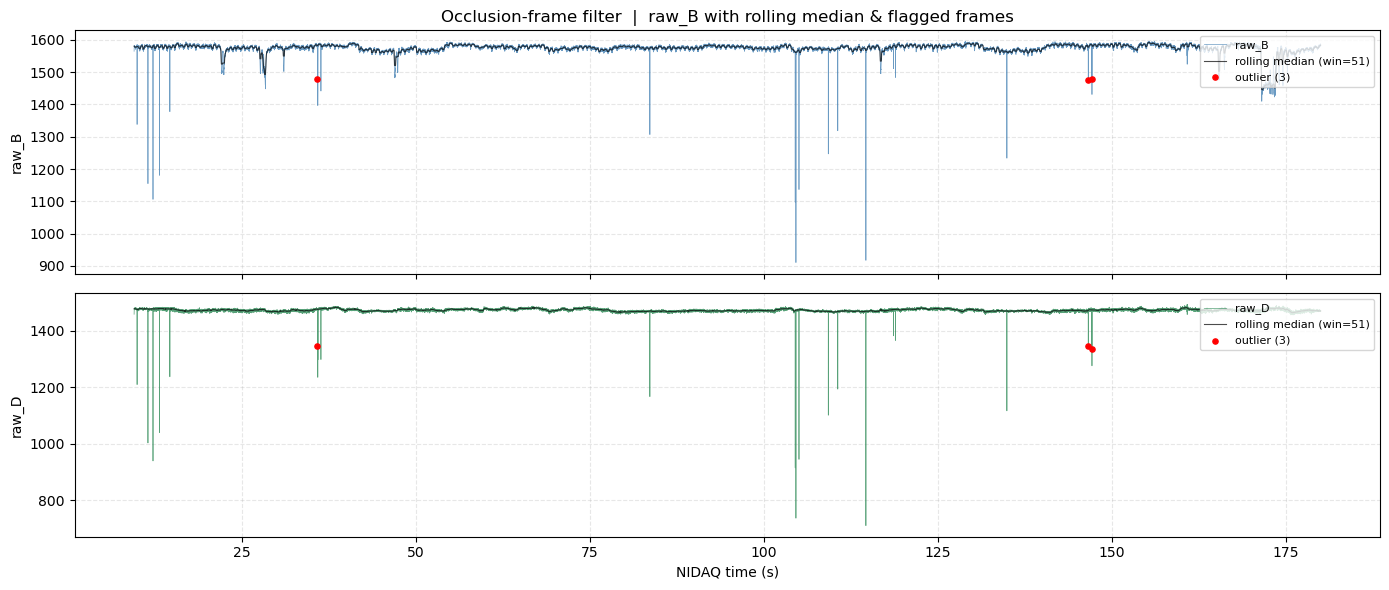

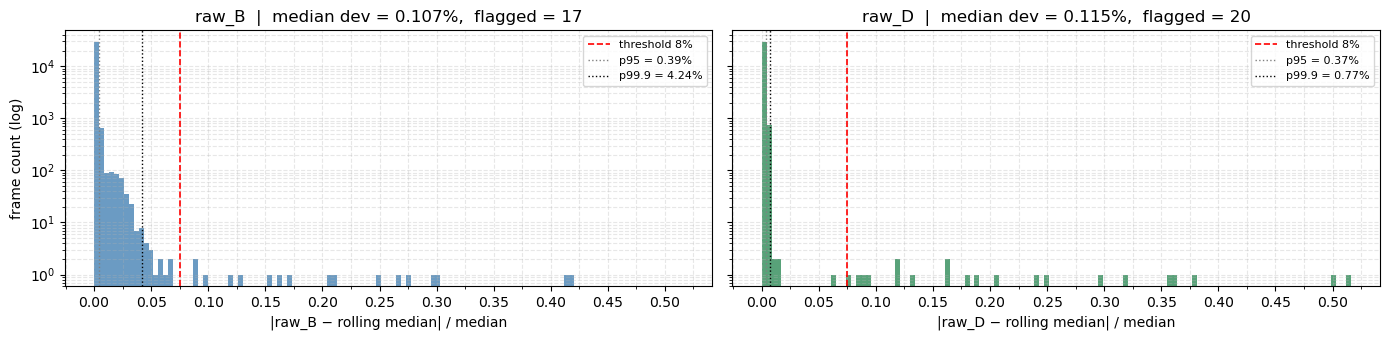

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# Block 2.5 — Occlusion-frame filter (post-alignment) / 遮挡帧过滤（对齐之后）
#
# Reads PHANTOM_CSV_OUT (written by Block 2 with columns
#   frame_number, time, wingbeat_frequency, normalized_intensity, raw_B, raw_D).
# Flags frames whose raw_B or raw_D deviates from its local rolling median by
# more than REL_THRESH (default 0.10 = 10%). Sets normalized_intensity to NaN
# on those rows so Block 3 / Block 6 automatically drop / interpolate over them.
# The CSV keeps all rows (frame_number + time) for auditability.
#
# Runs after end-alignment on purpose: diagnostics are in NIDAQ time.
# ═══════════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# ── 参数 / Parameters ─────────────────────────────────────────────────────────
ROLL_WIN     = 51     # 居中滚动窗口（帧）；Phantom fps 通常 ~1-6 kHz → 窗口覆盖 ~10-50 ms
REL_THRESH   = 0.075   # |raw - median| / median 超过该比例即视为离群（10%）0
MIN_MEDIAN   = 50.0   # 滚动中位数 < 该值时跳过（避免 0 附近除法爆炸）

df = pd.read_csv(PHANTOM_CSV_OUT)
for col in ("raw_B", "raw_D", "normalized_intensity", "time"):
    if col not in df.columns:
        raise RuntimeError(
            f"CSV 缺少列 `{col}` —— 请先运行 Block 2（会写入 raw_B/raw_D）。"
        )

N = len(df)
print(f"Loaded {N} rows from {PHANTOM_CSV_OUT}")

# 居中滚动中位数 / centered rolling median (NaN-safe; min_periods=1 so edges still evaluated)
med_B = df["raw_B"].rolling(ROLL_WIN, center=True, min_periods=1).median()
med_D = df["raw_D"].rolling(ROLL_WIN, center=True, min_periods=1).median()

with np.errstate(divide="ignore", invalid="ignore"):
    dev_B = np.where(med_B >= MIN_MEDIAN,
                     np.abs(df["raw_B"].values - med_B.values) / med_B.values,
                     0.0)
    dev_D = np.where(med_D >= MIN_MEDIAN,
                     np.abs(df["raw_D"].values - med_D.values) / med_D.values,
                     0.0)

# 任一通道超阈值即视为遮挡；原始 NaN 不算离群
already_nan = df["normalized_intensity"].isna().values
flag_B = dev_B > REL_THRESH
flag_D = dev_D > REL_THRESH
outlier = (flag_B | flag_D) & ~already_nan

n_out = int(outlier.sum())
print(f"Rolling window          : {ROLL_WIN} frames (centered)")
print(f"Relative threshold      : {REL_THRESH*100:.1f}%  (on both raw_B and raw_D)")
print(f"Frames flagged (B)      : {int(flag_B.sum())}")
print(f"Frames flagged (D)      : {int(flag_D.sum())}")
print(f"Frames flagged (B | D)  : {n_out}  ({n_out / max(N,1) * 100:.2f}%)")

if n_out > 0:
    shown = df.loc[outlier, ["frame_number", "time", "raw_B", "raw_D", "normalized_intensity"]].head(15)
    print("First flagged rows (up to 15):")
    print(shown.to_string(index=False))

# ── 将离群帧的 normalized_intensity 置为 NaN；保留其余列 ─────────────────────────
df.loc[outlier, "normalized_intensity"] = np.nan
df["occlusion_outlier"] = outlier.astype(np.int8)
df.to_csv(PHANTOM_CSV_OUT, index=False)
print(f"CSV updated (normalized_intensity → NaN on outliers, occlusion_outlier flag added): {PHANTOM_CSV_OUT}")

# ── 诊断图：raw_B + 滚动中位数 + 标记离群点 ──────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
t = df["time"].values

ax = axes[0]
ax.plot(t, df["raw_B"].values, color="steelblue", linewidth=0.5, alpha=0.8, label="raw_B")
ax.plot(t, med_B.values, color="black", linewidth=0.8, alpha=0.7, label=f"rolling median (win={ROLL_WIN})")
if n_out > 0:
    ax.scatter(t[outlier], df["raw_B"].values[outlier], s=14, color="red",
               zorder=5, label=f"outlier ({n_out})")
ax.set_ylabel("raw_B")
ax.set_title("Occlusion-frame filter  |  raw_B with rolling median & flagged frames")
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, linestyle="--", alpha=0.3)

ax = axes[1]
ax.plot(t, df["raw_D"].values, color="seagreen", linewidth=0.5, alpha=0.8, label="raw_D")
ax.plot(t, med_D.values, color="black", linewidth=0.8, alpha=0.7, label=f"rolling median (win={ROLL_WIN})")
if n_out > 0:
    ax.scatter(t[outlier], df["raw_D"].values[outlier], s=14, color="red",
               zorder=5, label=f"outlier ({n_out})")
ax.set_ylabel("raw_D")
ax.set_xlabel("NIDAQ time (s)")
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()
plt.close(fig)

# ── Deviation distribution (log-y histogram of |raw − rolling_median| / median) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5), sharey=True)
bins = np.linspace(0.0, max(float(np.nanmax(dev_B)), float(np.nanmax(dev_D)), REL_THRESH * 1.5), 120)
for ax, dev, raw_name, flag, color in (
    (axes[0], dev_B, "raw_B", flag_B, "steelblue"),
    (axes[1], dev_D, "raw_D", flag_D, "seagreen"),
):
    ax.hist(dev, bins=bins, color=color, alpha=0.8, edgecolor="none")
    ax.axvline(REL_THRESH, color="red", linestyle="--", linewidth=1.2,
               label=f"threshold {REL_THRESH*100:.0f}%")
    q50 = float(np.nanquantile(dev, 0.50))
    q95 = float(np.nanquantile(dev, 0.95))
    q999 = float(np.nanquantile(dev, 0.999))
    ax.axvline(q95, color="gray", linestyle=":", linewidth=1,
               label=f"p95 = {q95*100:.2f}%")
    ax.axvline(q999, color="black", linestyle=":", linewidth=1,
               label=f"p99.9 = {q999*100:.2f}%")
    ax.set_yscale("log")
    ax.set_xlabel(f"|{raw_name} − rolling median| / median")
    ax.xaxis.set_major_locator(MultipleLocator(0.05))
    ax.xaxis.set_minor_locator(MultipleLocator(0.025))
    ax.set_title(f"{raw_name}  |  median dev = {q50*100:.3f}%,  flagged = {int(flag.sum())}")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, which="both", linestyle="--", alpha=0.3)
axes[0].set_ylabel("frame count (log)")
plt.tight_layout()
plt.show()
plt.close(fig)

# Block 3 — Spiracle intensity: normalize → rescale (0–1)

**Purpose**: derive **`rescaled_intensity`** from **`normalized_intensity`** in `*_phantom_trigger_timedstamp.csv` and write it back to the same file.

- **Input**: column 4 (`normalized_intensity`) = ROI spiracle intensity normalized to the whole frame (pre-filled by your experiment pipeline).
- **Rescale**: over all samples that have an intensity value, linearly rescale using the **1st percentile → 0** and **99th percentile → 1**, producing **`rescaled_intensity`** (values may fall outside 0–1 where the signal exceeds the reference points).
- **X axis**: NIDAQ **`time`**; supports interactive browsing and **Save SVG**.

---

# Block 3 — 气门强度：归一化 → 重标度（0–1）

**目的**：在 `*_phantom_trigger_timedstamp.csv` 中由 **`normalized_intensity`** 生成 **`rescaled_intensity`**，并写回同一文件。

- **输入**：第 4 列（或列名 `normalized_intensity`）为 ROI 气门强度相对整帧的归一化值（按你实验 pipeline 事先填好）。
- **重标度**：在所有「有强度」的样本上，以 **第 1 百分位 → 0**、**第 99 百分位 → 1** 做线性重缩放，得到 **`rescaled_intensity`**（信号超出参考点时可能落在 0–1 之外）。
- **横轴**：NIDAQ **`time`**；支持交互浏览与 **Save SVG**。


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# Block 3 — Rescale spiracle intensity to [0, 1] / 强度重标度并写回 CSV
#
# Reads PHANTOM_CSV_OUT (from Block 2); column 4 = normalized_intensity → rescaled_intensity (top/bottom 5 means).
# Interactive plot + Save SVG; updates same CSV.
#
# Requires: pandas, numpy, matplotlib, ipywidgets
# ═══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import ipywidgets as widgets
from ipywidgets import HBox, VBox, Output, FloatRangeSlider, FloatText, Button

# ── 文件路径 / File path ─────────────────────────────────────────────────────────────────
CSV_FILE = PHANTOM_CSV_OUT

# ── 加载与清洗 / Load + clean ──────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_FILE)
# normalized_intensity 已由 Block 2 直接从 *_PhantomCamera.xlsx 第 5 列写入
# normalized_intensity is already written by Block 2 (xlsx column E, end-anchored)
if "normalized_intensity" not in df.columns:
    raise RuntimeError(
        "CSV 缺少 normalized_intensity 列 —— 请先运行 Block 2（会从 xlsx 按尾端对齐写入）。"
    )
print(f"Loaded {len(df)} rows")
print(df.head(10).to_string(index=False))

# 仅保留时间与强度均有值的行 / Keep only rows where BOTH time and intensity are present
df_valid = df.dropna(subset=["time", "normalized_intensity"]).copy()
df_valid = df_valid.sort_values("time").reset_index(drop=True)

print(f"\nRows with both values : {len(df_valid)}")
print(f"Rows dropped (NaN)    : {len(df) - len(df_valid)}")
print(f"Time range            : {df_valid['time'].min():.4f} – "
      f"{df_valid['time'].max():.4f} s")
print(f"Intensity range       : {df_valid['normalized_intensity'].min():.4f} – "
      f"{df_valid['normalized_intensity'].max():.4f}")

# ── 重缩放强度（1% 分位数=0，99% 分位数=1）/ Rescale intensity (percentile-based) ─────────
raw_y  = df_valid["normalized_intensity"].values
p_low  = np.nanpercentile(raw_y, 1.0)
p_high = np.nanpercentile(raw_y, 99.0)

df_valid["rescaled_intensity"] = (raw_y - p_low) / (p_high - p_low)

print(f"\nRescaling reference points (percentile-based):")
print(f"  1st  percentile (→ 0) : {p_low:.4f}")
print(f"  99th percentile (→ 1) : {p_high:.4f}")
print(f"Rescaled range          : {df_valid['rescaled_intensity'].min():.4f} – "
      f"{df_valid['rescaled_intensity'].max():.4f}")
print(f"  (values outside 0–1 are possible if signal exceeds reference points)")

# 保存带 rescaled_intensity 列的更新后的 CSV / Save updated CSV with rescaled_intensity
df_valid.to_csv(CSV_FILE, index=False)
print(f"\nCSV updated with rescaled_intensity column: {CSV_FILE}")

x = df_valid["time"].values
y = df_valid["rescaled_intensity"].values

t_min = float(x[0])
t_max = float(x[-1])

# ── 绘图函数 / Draw function ─────────────────────────────────────────────────────────────
def draw(t0, t1, out):
    mask  = (x >= t0) & (x <= t1)
    x_win = x[mask]
    y_win = y[mask]

    with out:
        out.clear_output(wait=True)

        if len(x_win) == 0:
            print("No data in this window.")
            return

        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(x_win, y_win, color="steelblue", linewidth=1.0)
        ax.set_xlabel("Time (s) — NIDAQ", fontsize=12)
        ax.set_ylabel("Rescaled intensity", fontsize=12)
        ax.set_title(
            f"Rescaled intensity vs time  |  {t0:.3f} – {t1:.3f} s  "
            f"({mask.sum()} frames)",
            fontsize=11,
        )
        ax.set_xlim(t0, t1)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=10))
        ax.grid(True, linestyle="--", alpha=0.35)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

# ── 控件 / Widgets ───────────────────────────────────────────────────────────────────
out = Output()

slider = FloatRangeSlider(
    value=[t_min, t_max], min=t_min, max=t_max, step=0.01,
    description="Window (s):", continuous_update=False,
    layout=widgets.Layout(width="750px"),
    style={"description_width": "90px"},
)
t_start_box = FloatText(value=t_min, description="Start (s):", step=0.1,
                         layout=widgets.Layout(width="170px"))
t_end_box   = FloatText(value=t_max, description="End (s):",   step=0.1,
                         layout=widgets.Layout(width="170px"))

btn_full  = Button(description="Full trace", button_style="",        layout=widgets.Layout(width="100px"))
btn_reset = Button(description="Reset",      button_style="warning", layout=widgets.Layout(width="80px"))
btn_save  = Button(description="Save SVG",   button_style="info",    layout=widgets.Layout(width="90px"))

def on_slider(change):
    t0, t1 = change["new"]
    t_start_box.value = round(t0, 4)
    t_end_box.value   = round(t1, 4)
    draw(t0, t1, out)

def on_text(_):
    t0 = max(t_min, min(t_start_box.value, t_end_box.value - 0.01))
    t1 = min(t_max, max(t_end_box.value,   t_start_box.value + 0.01))
    slider.value = (t0, t1)

def on_full(_):  slider.value = (t_min, t_max)
def on_reset(_): slider.value = (t_min, t_max)

def on_save(_):
    t0, t1  = slider.value
    mask    = (x >= t0) & (x <= t1)
    out_svg = CSV_FILE.replace(".csv", f"_rescaled_{t0:.2f}s_{t1:.2f}s.svg")
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(x[mask], y[mask], color="steelblue", linewidth=1.0)
    ax.set_xlabel("Time (s) — NIDAQ", fontsize=12)
    ax.set_ylabel("Rescaled intensity", fontsize=12)
    ax.set_title(f"Rescaled intensity vs time  |  {t0:.3f} – {t1:.3f} s", fontsize=11)
    ax.set_xlim(t0, t1)
    ax.grid(True, linestyle="--", alpha=0.35)
    plt.tight_layout()
    plt.savefig(out_svg, format="svg")
    plt.close()
    print(f"Saved: {out_svg}")

slider.observe(on_slider, names="value")
t_start_box.observe(on_text, names="value")
t_end_box.observe(on_text,   names="value")
btn_full.on_click(on_full)
btn_reset.on_click(on_reset)
btn_save.on_click(on_save)

controls = VBox([
    slider,
    HBox([t_start_box, t_end_box, btn_full, btn_reset, btn_save])
])
display(controls, out)
draw(t_min, t_max, out)


Loaded 30009 rows
 frame_number    time  wingbeat_frequency  normalized_intensity    raw_B    raw_D  occlusion_outlier
            1 9.54550          177.618626              1.073101 1564.586 1458.005                  0
            2 9.55115          177.782976              1.070706 1575.674 1471.622                  0
            3 9.55670          177.651496              1.070263 1577.382 1473.826                  0
            4 9.56240          177.782976              1.071370 1582.729 1477.294                  0
            5 9.56795          177.782976              1.071217 1580.774 1475.681                  0
            6 9.57355          177.454277              1.071213 1581.288 1476.166                  0
            7 9.57920          177.782976              1.069609 1579.799 1476.987                  0
            8 9.58475          178.013065              1.069263 1577.913 1475.702                  0
            9 9.59045          178.013065              1.072267 1581.338 

Output()

TypeError: draw() takes 2 positional arguments but 3 were given

TypeError: draw() takes 2 positional arguments but 3 were given

# Block 4 — Basler TTL diagnostic view

**Purpose**: like Block 1, interactively inspect the **Basler camera trigger** (exports no analysis table). Run Block 1 first to load `Data` and the time axis.

- **Signal**: **`Data[8,:]`** (AI 7) = Basler trigger waveform.
- **Use**: confirm trigger density, voltage range, and any glitches before running Block 5 for edge detection and CSV export.

---

# Block 4 — Basler TTL 诊断视图

**目的**：与 Block 1 类似，交互查看 **Basler 相机触发**（不导出分析表）。须先运行 Block 1 以加载 `Data` 与时间轴。

- **信号**：**`Data[8,:]`**（AI 7）= Basler 触发波形。
- **用途**：确认触发密度、电压范围与异常毛刺，再运行 Block 5 做边沿检测与 CSV。


In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# Block 4 — Basler TTL trace (diagnostic) / Basler TTL 波形（诊断）
#
# Uses Data[8,:] (AI 7) and time_s from Block 1. Interactive window + Save PNG. No CSV export.
#
# Requires: scipy, numpy, matplotlib, ipywidgets
# ═══════════════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from ipywidgets import interact, FloatRangeSlider, FloatText, HBox, VBox, Button, Output
import ipywidgets as widgets

# 使用 Basler 信号（Data 第 9 行，即 AI 7），覆盖 Cell 1 中的 row
row = Data[8, :]  # AI 7, Basler cameras trigger
t_min = float(time_s[0])
t_max = float(time_s[-1])

print(f"Data shape  : {Data.shape}")
print(f"Time range  : {t_min:.4f} – {t_max:.4f} s")
print(f"Row Data range : {row.min():.4f} – {row.max():.4f} V")

# ── 交互式绘图 / Interactive plot ──────────────────────────────────────────────────────────
out = Output()

t_start_box = FloatText(value=t_min, description="Start (s):", step=0.1, layout=widgets.Layout(width="160px"))
t_end_box   = FloatText(value=t_max, description="End (s):",   step=0.1, layout=widgets.Layout(width="160px"))

slider = FloatRangeSlider(
    value=[t_min, t_max],
    min=t_min, max=t_max, step=0.05,
    description="Window (s):",
    continuous_update=False,
    layout=widgets.Layout(width="700px"),
    style={"description_width": "90px"},
)

reset_btn  = Button(description="Reset",       button_style="warning", layout=widgets.Layout(width="90px"))
save_btn   = Button(description="Save PNG",    button_style="info",    layout=widgets.Layout(width="90px"))

def draw(t0, t1):
    mask = (time_s >= t0) & (time_s <= t1)
    t_win = time_s[mask]
    y_win = row[mask]

    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(14, 4))
        ax.plot(t_win, y_win, color="steelblue", linewidth=0.7, alpha=0.9)
        ax.set_xlabel("Time (s)", fontsize=12)
        ax.set_ylabel("Voltage (V)", fontsize=12)
        ax.set_title(
            f"Basler Trigger Signal  |  window: {t0:.3f} – {t1:.3f} s\n",
            fontsize=11,
        )
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=10))
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.set_xlim(t0, t1)
        plt.tight_layout()
        plt.show()

# ── 同步：滑块 ↔ 文本框 / Sync: slider ↔ text boxes ─────────────────────────────────────────────────
def on_slider_change(change):
    t0, t1 = change["new"]
    t_start_box.value = t0
    t_end_box.value   = t1
    draw(t0, t1)

def on_text_change(_):
    t0 = max(t_min, min(t_start_box.value, t_end_box.value - 0.01))
    t1 = min(t_max, max(t_end_box.value,   t_start_box.value + 0.01))
    slider.value = (t0, t1)   # triggers slider observer → draw

def on_reset(_):
    slider.value = (t_min, t_max)

def on_save(_):
    t0, t1 = slider.value
    mask  = (time_s >= t0) & (time_s <= t1)
    fname = f"basler_trigger_{t0:.2f}s_to_{t1:.2f}s.png"
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(time_s[mask], row[mask], color="steelblue", linewidth=0.7, alpha=0.9)
    ax.set_xlabel("Time (s)", fontsize=12)
    ax.set_ylabel("Voltage (V)", fontsize=12)
    ax.set_title(f"Basler Trigger Signal |  {t0:.3f} – {t1:.3f} s", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_xlim(t0, t1)
    plt.tight_layout()
    plt.savefig(fname, dpi=150)
    plt.close()
    print(f"Saved: {fname}")

slider.observe(on_slider_change, names="value")
t_start_box.observe(on_text_change, names="value")
t_end_box.observe(on_text_change,   names="value")
reset_btn.on_click(on_reset)
save_btn.on_click(on_save)

# ── 布局与显示 / Layout & display ──────────────────────────────────────────────────────────
controls = VBox([
    slider,
    HBox([t_start_box, t_end_box, reset_btn, save_btn])
])
display(controls, out)
draw(t_min, t_max)

Data shape  : (9, 3620000)
Time range  : 0.0000 – 181.0000 s
Row Data range : 0.0719 – 4.9919 V


Output()

# Block 5 — Basler timestamps + TopCamera wingbeat amplitude

**Purpose**: align **TopCamera** tracking results to the Basler rising edges and export `*_basler_trigger_timestamp.csv`.

- **Edges**: detect rising edges on **`Data[8,:]`** (threshold + debounce); **Frame *k*** = the *k*-th Basler rising edge in the entire NIDAQ recording, with its time read from **`Data[0,:]`**.
- **Recording window**: only edges within **rec_on～rec_off** are written; they are matched to TopCamera rows by **global frame number**.
- **`wingbeat_amplitude`** = LeftWing + RightWing + **3.1416** (matches the experiment/script convention).

---

# Block 5 — Basler 时间戳 + TopCamera 翼幅

**目的**：在 Basler 上升沿对齐 **TopCamera** 追踪结果，导出 `*_basler_trigger_timestamp.csv`。

- **边沿**：在 **`Data[8,:]`** 上检测上升沿（阈值 + 消抖）；**Frame *k*** = 全局第 *k* 个 Basler 上升沿，时间取自 **`Data[0,:]`**。
- **录制窗**：仅 **rec_on～rec_off** 内的沿参与输出；与 TopCamera 按**全局帧号**对齐。
- **`wingbeat_amplitude`** = LeftWing + RightWing + **3.1416**（与脚本约定一致）。


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# Block 5 — Basler edges + TopCamera → wingbeat_amplitude CSV
# Basler 上升沿 + TopCamera 左右翼 → *_basler_trigger_timestamp.csv
#
# Global frame index = k-th Basler rising edge; amplitude = LeftWing + RightWing + PI_REF.
#
# Requires: scipy, numpy, pandas, matplotlib, glob, ipywidgets
# ═══════════════════════════════════════════════════════════════════════════════
import glob
import os
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import ipywidgets as widgets
from ipywidgets import HBox, VBox, Output, FloatRangeSlider, FloatText, Button

PI_REF = 3.1416  # 与 LeftWing+RightWing 同单位相加

_mat_stem = os.path.splitext(MAT_FILE)[0]
BASLER_CSV_OUT = _mat_stem + "_basler_trigger_timestamp.csv"
print(f"CSV will be saved to:\n  {BASLER_CSV_OUT}")

mat = scipy.io.loadmat(MAT_FILE, squeeze_me=True, struct_as_record=False)
Data = mat["Data"]
phantom = mat["phantom"]

time_s = Data[0, :]
basler_ttl = Data[8, :]

sample_rate = float(len(time_s) / (time_s[-1] - time_s[0]))
t_min = float(time_s[0])
t_max = float(time_s[-1])

rec_on = float(phantom.rec_on_time_s)
rec_off = float(phantom.rec_off_time_s)

print(f"Duration              : {t_max:.3f} s")
print(f"Basler TTL range      : {basler_ttl.min():.3f} – {basler_ttl.max():.3f} V")
print(f"Phantom recording ON  : {rec_on:.6f} s")
print(f"Phantom recording OFF : {rec_off:.6f} s")

THRESHOLD = 1.5
DEADTIME_S = 0.002

binary = (basler_ttl >= THRESHOLD).astype(np.int8)
diff_sig = np.diff(binary, prepend=0)
all_rise_idx = np.where(diff_sig == 1)[0]

if len(all_rise_idx) > 0:
    deadtime_samples = int(DEADTIME_S * sample_rate)
    keep = [all_rise_idx[0]]
    for idx in all_rise_idx[1:]:
        if idx - keep[-1] >= deadtime_samples:
            keep.append(idx)
    all_rise_idx = np.array(keep)

all_rise_times = time_s[all_rise_idx]

mask_rec = (all_rise_times >= rec_on) & (all_rise_times <= rec_off)
rec_rise_idx = all_rise_idx[mask_rec]
rec_rise_times = all_rise_times[mask_rec]
n_rec = len(rec_rise_times)

print(f"\nTotal rising edges (debounced) : {len(all_rise_times)}")
print(f"Triggers inside recording      : {n_rec}")

if n_rec == 0:
    raise RuntimeError("No Basler triggers inside rec_on / rec_off.")

# ── TopCamera CSV ─────────────────────────────────────────────────────────────
_top_folder = os.path.dirname(MAT_FILE)
_mat_base = os.path.splitext(os.path.basename(MAT_FILE))[0]
_expected_path = os.path.join(_top_folder, f"{_mat_base}_TopCamera.csv")

if os.path.exists(_expected_path):
    TOPCAMERA_CSV = _expected_path
    print(f"\nTopCamera CSV: {TOPCAMERA_CSV}")
else:
    cands = glob.glob(os.path.join(_top_folder, f"{_mat_base}*_TopCamera*.csv"))
    cands = [p for p in cands if os.path.basename(p).lower().endswith("_topcamera.csv")]
    if len(cands) == 0:
        raise FileNotFoundError(
            f"找不到 {_mat_base}_TopCamera.csv（与 .mat 同目录）。\n期望: {_expected_path}"
        )
    if len(cands) > 1:
        raise RuntimeError(
            "多个 TopCamera 候选，请只保留一个或精确命名：\n" + "\n".join(sorted(cands))
        )
    TOPCAMERA_CSV = sorted(cands)[0]
    print(f"\nTopCamera CSV (fallback): {TOPCAMERA_CSV}")

_df_top = pd.read_csv(TOPCAMERA_CSV)

# 帧列：优先 "Frame"，否则列名含 frame（约定：第一列常为 Frames）
frame_col = None
for c in _df_top.columns:
    if str(c).strip().lower() == "frame":
        frame_col = c
        break
if frame_col is None:
    for c in _df_top.columns:
        if "frame" in str(c).lower():
            frame_col = c
            break
if frame_col is None:
    frame_col = _df_top.columns[0]

left_col = right_col = None
for c in _df_top.columns:
    cl = str(c).lower()
    if left_col is None and "left" in cl and "wing" in cl:
        left_col = c
for c in _df_top.columns:
    cl = str(c).lower()
    if right_col is None and "right" in cl and "wing" in cl:
        right_col = c

if left_col is None or right_col is None:
    raise ValueError(
        "无法识别 LeftWing / RightWing 列。\n列: " + str(list(_df_top.columns))
    )

print(f"TopCamera frame column : {frame_col}")
print(f"TopCamera Left column  : {left_col}")
print(f"TopCamera Right column : {right_col}")

left_vals = pd.to_numeric(_df_top[left_col], errors="coerce").values
right_vals = pd.to_numeric(_df_top[right_col], errors="coerce").values
frames_vals = pd.to_numeric(_df_top[frame_col], errors="coerce").values
wba_per_row = left_vals + right_vals + PI_REF

# ── 对齐定义（与实验约定一致）────────────────────────────────────────────────
# Frame 编号 k（从 1 起）= 整条 NIDAQ 记录里第 k 个 Basler TTL 上升沿；
# 该沿的 NIDAQ 时间为 all_rise_times[k-1]。
# 仅当 rec_on ≤ 时间 ≤ rec_off 时，该 Frame 才进入 Phantom 录制窗内的分析。
n_all = len(all_rise_times)
global_frame_indices = np.arange(1, n_all + 1, dtype=int)[mask_rec]

assert np.all(rec_rise_times >= rec_on - 1e-6) and np.all(
    rec_rise_times <= rec_off + 1e-6
), "内部错误：rec_rise_times 应全部落在 rec_on～rec_off"
print(
    f"Basler（窗内）: NIDAQ {rec_rise_times[0]:.6f} – {rec_rise_times[-1]:.6f} s  (rec_on={rec_on:.6f}, rec_off={rec_off:.6f})"
)
print(
    f"窗内有效全局 Frame（第 k 沿 ↔ Frame k）: {global_frame_indices[0]} … {global_frame_indices[-1]}  (共 {len(global_frame_indices)} 个)"
)

frame_to_wba = {}
for f, w in zip(frames_vals, wba_per_row):
    if np.isfinite(f) and np.isfinite(w):
        frame_to_wba[float(f)] = float(w)

wingbeat_amplitude = np.array(
    [frame_to_wba.get(float(k), np.nan) for k in global_frame_indices],
    dtype=float,
)
n_nan = int(np.sum(np.isnan(wingbeat_amplitude)))
if n_nan:
    print(
        f"  Warning: {n_nan} NaN — TopCamera 中缺少与上述全局 Frame 编号一致的行。"
    )

df_out = pd.DataFrame(
    {
        "frame_number_basler": global_frame_indices,
        "time": rec_rise_times,
        "wingbeat_amplitude": wingbeat_amplitude,
    }
)
df_out.to_csv(BASLER_CSV_OUT, index=False)
print(f"\nCSV saved: {BASLER_CSV_OUT}  ({len(df_out)} rows)")
print(df_out.head(10).to_string(index=False))

wba_rec = wingbeat_amplitude


def draw_panels(t0, t1, out):
    win_mask = (time_s >= t0) & (time_s <= t1)
    edge_mask = (all_rise_times >= t0) & (all_rise_times <= t1)
    rec_mask = (rec_rise_times >= t0) & (rec_rise_times <= t1)

    with out:
        out.clear_output(wait=True)
        fig, axes = plt.subplots(4, 1, figsize=(14, 12))

        ax = axes[0]
        ax.plot(
            time_s[win_mask],
            basler_ttl[win_mask],
            color="steelblue",
            linewidth=0.6,
            alpha=0.9,
            label="Basler TTL",
        )
        ymin, ymax = -0.3, 4.0
        if rec_on >= t0 and rec_on <= t1:
            ax.axvline(
                rec_on,
                color="lime",
                linewidth=1.5,
                linestyle="--",
                label=f"rec ON ({rec_on:.3f}s)",
            )
        if rec_off >= t0 and rec_off <= t1:
            ax.axvline(
                rec_off,
                color="tomato",
                linewidth=1.5,
                linestyle="--",
                label=f"rec OFF ({rec_off:.3f}s)",
            )
        ax.vlines(
            all_rise_times[edge_mask],
            ymin=ymin,
            ymax=ymax,
            color="orange",
            linewidth=0.8,
            alpha=0.6,
            label=f"all edges ({edge_mask.sum()})",
        )
        ax.axhline(
            THRESHOLD,
            color="gray",
            linestyle=":",
            linewidth=1,
            label=f"threshold ({THRESHOLD} V)",
        )
        ax.set_ylabel("Voltage (V)")
        ax.set_title(f"Basler TTL + all edges  |  {t0:.3f} – {t1:.3f} s")
        ax.legend(fontsize=8, loc="upper right")
        ax.set_xlim(t0, t1)
        ax.set_ylim(ymin, ymax)
        ax.grid(True, linestyle="--", alpha=0.3)

        ax = axes[1]
        ax.plot(time_s[win_mask], basler_ttl[win_mask], color="steelblue", linewidth=0.6, alpha=0.9)
        if rec_on >= t0 and rec_on <= t1:
            ax.axvline(rec_on, color="lime", linewidth=1.5, linestyle="--", label="rec ON")
        if rec_off >= t0 and rec_off <= t1:
            ax.axvline(rec_off, color="tomato", linewidth=1.5, linestyle="--", label="rec OFF")
        ax.vlines(
            rec_rise_times[rec_mask],
            ymin=ymin,
            ymax=ymax,
            color="red",
            linewidth=0.8,
            alpha=0.8,
            label=f"recorded ({rec_mask.sum()})",
        )
        ax.axhline(THRESHOLD, color="gray", linestyle=":", linewidth=1)
        ax.set_ylabel("Voltage (V)")
        ax.set_title(f"Recorded Basler triggers  |  {rec_mask.sum()} in window")
        ax.legend(fontsize=8, loc="upper right")
        ax.set_xlim(t0, t1)
        ax.set_ylim(ymin, ymax)
        ax.grid(True, linestyle="--", alpha=0.3)

        frame_nums_in_win = global_frame_indices[rec_mask]
        ax = axes[2]
        rec_rel_win = rec_rise_times[rec_mask]
        if len(rec_rel_win) > 1:
            ifi_ms = np.diff(rec_rel_win - rec_rel_win[0]) * 1000.0
            fn_ifi = global_frame_indices[rec_mask][1:]
            ax.plot(fn_ifi, ifi_ms, color="steelblue", linewidth=0.8, marker=".", markersize=3)
            ax.axhline(np.mean(ifi_ms), color="tomato", linestyle="--")
            ax.set_ylabel("IFI (ms)")
            ax.set_title("Inter-frame interval (Basler)")
            ax.grid(True, linestyle="--", alpha=0.3)
        else:
            ax.text(0.5, 0.5, "No IFI", ha="center", va="center", transform=ax.transAxes)

        ax = axes[3]
        if len(frame_nums_in_win) > 0:
            wba_win = wba_rec[rec_mask]
            ax.plot(
                frame_nums_in_win,
                wba_win,
                color="purple",
                linewidth=0.8,
                marker=".",
                markersize=3,
            )
            ax.axhline(
                np.nanmean(wba_win),
                color="tomato",
                linestyle="--",
                linewidth=1.2,
                label=f"mean {np.nanmean(wba_win):.3f}",
            )
            ax.set_xlabel("global Frame (rec_on～rec_off)")
            ax.set_ylabel("wingbeat_amplitude")
            ax.set_title(f"wingbeat_amplitude  |  {t0:.3f} – {t1:.3f} s")
            ax.legend(fontsize=9)
            ax.grid(True, linestyle="--", alpha=0.3)
        else:
            ax.text(
                0.5,
                0.5,
                "No data in window",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=11,
                color="gray",
            )

        plt.tight_layout()
        plt.show()


out2 = Output()

slider2 = FloatRangeSlider(
    value=[t_min, t_max],
    min=t_min,
    max=t_max,
    step=0.05,
    description="Window (s):",
    continuous_update=False,
    layout=widgets.Layout(width="750px"),
    style={"description_width": "90px"},
)
t_start_box2 = FloatText(
    value=t_min,
    description="Start (s):",
    step=0.1,
    layout=widgets.Layout(width="170px"),
)
t_end_box2 = FloatText(
    value=t_max,
    description="End (s):",
    step=0.1,
    layout=widgets.Layout(width="170px"),
)

btn_full2 = Button(description="Full trace", button_style="", layout=widgets.Layout(width="110px"))
btn_recwin2 = Button(
    description="Rec window", button_style="success", layout=widgets.Layout(width="110px")
)
btn_reset2 = Button(description="Reset", button_style="warning", layout=widgets.Layout(width="80px"))
btn_save2 = Button(description="Save PNG", button_style="info", layout=widgets.Layout(width="90px"))


def on_slider2(change):
    t0, t1 = change["new"]
    t_start_box2.value = round(t0, 4)
    t_end_box2.value = round(t1, 4)
    draw_panels(t0, t1, out2)


def on_text2(_):
    t0 = max(t_min, min(t_start_box2.value, t_end_box2.value - 0.01))
    t1 = min(t_max, max(t_end_box2.value, t_start_box2.value + 0.01))
    slider2.value = (t0, t1)


def on_full2(_):
    slider2.value = (t_min, t_max)


def on_recwin2(_):
    slider2.value = (max(t_min, rec_on - 1.0), min(t_max, rec_off + 1.0))


def on_reset2(_):
    slider2.value = (t_min, t_max)


def on_save2(_):
    t0, t1 = slider2.value
    fname = _mat_stem + f"_basler_triggers_{t0:.2f}s_{t1:.2f}s.png"
    win_mask = (time_s >= t0) & (time_s <= t1)
    edge_mask = (all_rise_times >= t0) & (all_rise_times <= t1)
    rec_mask = (rec_rise_times >= t0) & (rec_rise_times <= t1)
    fig, axes = plt.subplots(4, 1, figsize=(14, 12))
    ymin, ymax = -0.3, 4.0
    for ax, vlines, title_suffix in zip(
        axes[:2],
        [all_rise_times[edge_mask], rec_rise_times[rec_mask]],
        ["all edges", "recorded triggers"],
    ):
        ax.plot(time_s[win_mask], basler_ttl[win_mask], color="steelblue", linewidth=0.6)
        ax.vlines(vlines, ymin=ymin, ymax=ymax, color="red", linewidth=0.8, alpha=0.7)
        ax.axhline(THRESHOLD, color="gray", linestyle=":", linewidth=1)
        if rec_on >= t0 and rec_on <= t1:
            ax.axvline(rec_on, color="lime", linestyle="--", linewidth=1.5)
        if rec_off >= t0 and rec_off <= t1:
            ax.axvline(rec_off, color="tomato", linestyle="--", linewidth=1.5)
        ax.set_xlim(t0, t1)
        ax.set_ylim(ymin, ymax)
        ax.set_ylabel("Voltage (V)")
        ax.set_title(title_suffix)
        ax.grid(True, linestyle="--", alpha=0.3)
    rec_rel_win = rec_rise_times[rec_mask]
    if len(rec_rel_win) > 1:
        ifi_ms = np.diff(rec_rel_win - rec_rel_win[0]) * 1000.0
        frame_nums = np.where(rec_mask)[0][1:] + 1
        axes[2].plot(frame_nums, ifi_ms, color="steelblue", linewidth=0.8, marker=".", markersize=3)
        axes[2].axhline(np.mean(ifi_ms), color="tomato", linestyle="--")
        axes[2].set_ylabel("IFI (ms)")
        axes[2].set_title("Inter-frame interval")
        axes[2].grid(True, linestyle="--", alpha=0.3)
    frame_nums_in_win = global_frame_indices[rec_mask]
    if len(frame_nums_in_win) > 0:
        wba_win = wba_rec[rec_mask]
        axes[3].plot(
            frame_nums_in_win,
            wba_win,
            color="purple",
            linewidth=0.8,
            marker=".",
            markersize=3,
        )
        axes[3].axhline(np.nanmean(wba_win), color="tomato", linestyle="--", linewidth=1.2)
        axes[3].set_xlabel("global Frame (rec_on～rec_off)")
        axes[3].set_ylabel("wingbeat_amplitude")
        axes[3].set_title("wingbeat_amplitude")
        axes[3].grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.savefig(fname, dpi=150)
    plt.close()
    print(f"Saved: {fname}")


slider2.observe(on_slider2, names="value")
t_start_box2.observe(on_text2, names="value")
t_end_box2.observe(on_text2, names="value")
btn_full2.on_click(on_full2)
btn_recwin2.on_click(on_recwin2)
btn_reset2.on_click(on_reset2)
btn_save2.on_click(on_save2)

controls2 = VBox(
    [
        slider2,
        HBox([t_start_box2, t_end_box2, btn_full2, btn_recwin2, btn_reset2, btn_save2]),
    ]
)
display(controls2, out2)
draw_panels(t_min, t_max, out2)


CSV will be saved to:
  C:\Users\Lylah\Desktop\data_processing\2025_1226_141929_SpMN4_ChR_EMG_SpMN4_ChR_5d_F_Fly1_Trial1_3000msx3_thorax_basler_trigger_timestamp.csv


KeyError: 'phantom'

# Block 6 — Merge Phantom / Basler, resample to 20 kHz, infer flight power

**Purpose**: align the two asynchronous CSVs onto a common **20 kHz** time grid, compute **`inferred_flight_power`**, and save **`*_combined.csv`**.

- **Inputs**: `*_phantom_trigger_timedstamp.csv` (must contain `rescaled_intensity`, `wingbeat_frequency`) and `*_basler_trigger_timestamp.csv` (must contain `wingbeat_amplitude`); all times are absolute NIDAQ time.
- **Resampling**: a uniform grid over `[min(t), max(t)]` with **linear interpolation** of each of the three series; **`time_s`** = absolute NIDAQ time (s).
- **Power**: **P\*** = P_pro\* + P_ind\* (Φ = wingbeat amplitude, n = frequency; constants `C_PRO`, `C_IND` are set in the code).
- **Reference sine**: column **`stimulus_sine`**, period **20 s**, range **[-1, 1]**; **0** at **t = 60 s** and **+1** (peak) at **t = 65 s**. The preview shows up to five channels.

---

# Block 6 — 合并 Phantom / Basler，20 kHz 重采样与推断飞行功率

**目的**：将两条异步 CSV 对齐到统一 **20 kHz** 时间网格，计算 **`inferred_flight_power`**，保存 **`*_combined.csv`**。

- **输入**：`*_phantom_trigger_timedstamp.csv`（须含 `rescaled_intensity`, `wingbeat_frequency`）与 `*_basler_trigger_timestamp.csv`（须含 `wingbeat_amplitude`）；时间均为 NIDAQ **绝对时间**。
- **重采样**：在 `[min(t), max(t)]` 上均匀采样，对三条序列分别**线性插值**；**`time_s`** = NIDAQ **绝对时间**（秒）。
- **功率**：**P\*** = P_pro\* + P_ind\*（Φ = 翼幅，n = 频率；常数见代码注释）。
- **参考正弦**：列 **`stimulus_sine`**，周期 **20 s**，**[-1, 1]**；在 **t = 60 s** 为 **0**，在 **t = 65 s** 为 **+1**（峰值）。五通道预览图。


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Block 6 — Merge CSVs, 20 kHz grid, inferred flight power → _combined.csv
# 合并 Phantom/Basler 序列，线性插值 + 机械功率模型，导出 *_combined.csv
#
# Prereq: Block 3 & 5 CSVs. time_s starts at 0; columns see header comment in prior markdown.
#
# Requires: numpy, pandas, matplotlib, ipywidgets
# ═══════════════════════════════════════════════════════════════════════════════
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import ipywidgets as widgets
from ipywidgets import HBox, VBox, Output, FloatRangeSlider, FloatText, Button

# ── Plot toggles / 绘图开关 ───────────────────────────────────────────────────
# rescaled_intensity 面板：若 Phantom CSV 没有 rescaled_intensity 列，会自动禁用，
#   其余通道照常绘制（无需先运行 Block 3）。也可手动设为 False 关闭。
# stimulus_sine 面板：参考正弦，可按需开关。
PLOT_RESCALED_INTENSITY = True   # show the rescaled_intensity panel (auto-disabled if data missing)
PLOT_STIMULUS_SINE      = True   # show the reference stimulus-sine panel

FS = 20_000.0
C_PRO = 1.44e-7
C_IND = 10.5

YLIMS = {
    "rescaled_intensity":    (0.0, 1.0),
    "wingbeat_amplitude":    (3.14, 6.28),
    "wingbeat_frequency":    (100.0, 300.0),
    "inferred_flight_power": (100.0, 400.0),
}

_mat_stem = os.path.splitext(MAT_FILE)[0]
phantom_csv = _mat_stem + "_phantom_trigger_timedstamp.csv"
basler_csv = _mat_stem + "_basler_trigger_timestamp.csv"
combined_csv = _mat_stem + "_combined.csv"

print("Loading:")
print(f"  {phantom_csv}")
print(f"  {basler_csv}")

phantom_df = pd.read_csv(phantom_csv)
basler_df = pd.read_csv(basler_csv)

# rescaled_intensity 可选：缺列时自动禁用对应面板，但仍可绘制其它所有通道
has_rescaled = "rescaled_intensity" in phantom_df.columns
if PLOT_RESCALED_INTENSITY and not has_rescaled:
    print("⚠ rescaled_intensity 不在 Phantom CSV 中 —— 跳过该面板（如需此通道，请先运行 Block 3）。")
show_rescaled = PLOT_RESCALED_INTENSITY and has_rescaled

phantom_times = pd.to_numeric(phantom_df["time"], errors="coerce").values
if has_rescaled:
    rescaled_int = pd.to_numeric(phantom_df["rescaled_intensity"], errors="coerce").values
else:
    rescaled_int = np.full_like(phantom_times, np.nan, dtype=float)
wbf_phantom = pd.to_numeric(phantom_df["wingbeat_frequency"], errors="coerce").values

if "wingbeat_amplitude" not in basler_df.columns:
    raise RuntimeError("Basler CSV 需含 wingbeat_amplitude（先运行 Block 5）。")
basler_times = pd.to_numeric(basler_df["time"], errors="coerce").values
wba_basler = pd.to_numeric(basler_df["wingbeat_amplitude"], errors="coerce").values

t_min_abs = np.nanmin([np.nanmin(phantom_times), np.nanmin(basler_times)])
t_max_abs = np.nanmax([np.nanmax(phantom_times), np.nanmax(basler_times)])

# Use linspace (not arange) so the endpoint is exact and the sample count
# is robust to floating-point accumulation across ~2 M points at 20 kHz.
n_grid = int(round((t_max_abs - t_min_abs) * FS)) + 1
time_grid_abs = np.linspace(t_min_abs, t_max_abs, n_grid)
time_s = time_grid_abs

print(f"\n重采样：均匀网格 {FS:.0f} Hz，线性插值；绝对时间范围 [{t_min_abs:.6f}, {t_max_abs:.6f}] s")
print(f"网格点数: {len(time_s)}  |  NIDAQ 绝对时间范围 {time_s[0]:.6f} 到 {time_s[-1]:.6f} s")


def interp_irregular(t, y, xq):
    """分段线性插值；t,y 中无效点剔除；xq 可超出范围 → 边界外为 NaN。"""
    m = np.isfinite(t) & np.isfinite(y)
    t = t[m].astype(float)
    y = y[m].astype(float)
    if t.size == 0:
        return np.full(xq.shape, np.nan)
    order = np.argsort(t)
    t, y = t[order], y[order]
    uniq = np.concatenate([[True], np.diff(t) > 1e-15])
    t, y = t[uniq], y[uniq]
    if t.size < 2:
        return np.full(xq.shape, np.nan)
    return np.interp(xq, t, y, left=np.nan, right=np.nan)


ri_grid = interp_irregular(phantom_times, rescaled_int, time_grid_abs)
wbf_grid = interp_irregular(phantom_times, wbf_phantom, time_grid_abs)
wba_grid = interp_irregular(basler_times, wba_basler, time_grid_abs)

Phi = wba_grid
n = wbf_grid

inferred_power = np.full_like(Phi, np.nan, dtype=float)
ok = np.isfinite(Phi) & np.isfinite(n) & (Phi > 0) & (n > 0)
P_pro_ok = C_PRO * (Phi[ok] ** 3) * (n[ok] ** 3)
P_ind_ok = C_IND * (Phi[ok] ** (-0.5))
inferred_power[ok] = P_pro_ok + P_ind_ok

# 20 s 周期参考正弦，归一化到 [-1, 1]：NIDAQ t=60 s 时为 0，t=65 s 时为 +1（峰值）
# 始终计算并写入 CSV；PLOT_STIMULUS_SINE 仅控制是否绘制该面板。
SINE_PERIOD_S = 20.0
SINE_ZERO_AT_S = 60.0
stimulus_sine = np.sin((time_s - SINE_ZERO_AT_S) * (2 * np.pi / SINE_PERIOD_S))

combined_df = pd.DataFrame(
    {
        "time_s": time_s,
        "rescaled_intensity": ri_grid,
        "wingbeat_amplitude": wba_grid,
        "wingbeat_frequency": wbf_grid,
        "inferred_flight_power": inferred_power,
        "stimulus_sine": stimulus_sine,
    }
)
combined_df.to_csv(combined_csv, index=False)
print(f"\n已保存: {combined_csv}  ({len(combined_df)} rows)")
print(combined_df.head(8).to_string(index=False))

x = time_s
y_ri = ri_grid
y_wba = wba_grid
y_wbf = wbf_grid
y_pwr = inferred_power
y_sin = stimulus_sine

# ── 按开关构建当前要绘制的面板列表 / Build the active panel list from the toggles ──
# kind="data" → 仅在三条基础信号共同有效区间绘制；kind="sine" → 整窗绘制。
SINE_TITLE = (
    f"20 s sine (0 @ {SINE_ZERO_AT_S:.0f} s, "
    f"peak +1 @ {SINE_ZERO_AT_S + SINE_PERIOD_S / 4:.0f} s)  |  [-1, 1]"
)
panels = []
if show_rescaled:
    panels.append({"y": y_ri, "ylabel": "rescaled_intensity", "title": "rescaled_intensity",
                   "color": "steelblue", "ylim": YLIMS["rescaled_intensity"], "kind": "data"})
panels.append({"y": y_wba, "ylabel": "wingbeat_amplitude", "title": "wingbeat_amplitude",
               "color": "mediumpurple", "ylim": YLIMS["wingbeat_amplitude"], "kind": "data"})
panels.append({"y": y_wbf, "ylabel": "wingbeat_frequency (Hz)", "title": "wingbeat_frequency",
               "color": "seagreen", "ylim": YLIMS["wingbeat_frequency"], "kind": "data"})
panels.append({"y": y_pwr, "ylabel": "inferred_flight_power", "title": "inferred_flight_power",
               "color": "darkorange", "ylim": YLIMS["inferred_flight_power"], "kind": "data"})
if PLOT_STIMULUS_SINE:
    panels.append({"y": y_sin, "ylabel": "stimulus sine", "title": SINE_TITLE,
                   "color": "gray", "ylim": (-1.05, 1.05), "kind": "sine"})

# 共同有效区间：仅由启用的数据通道决定（正弦除外）
base_signals = [y_wba, y_wbf]
if show_rescaled:
    base_signals.append(y_ri)
common_valid = np.ones(x.shape, dtype=bool)
for _s in base_signals:
    common_valid &= np.isfinite(_s)

if np.any(common_valid):
    t_lo = float(np.nanmin(x[common_valid]))
    t_hi = float(np.nanmax(x[common_valid]))
else:
    t_lo = float(x[0])
    t_hi = float(x[-1])


def _draw_panels(axes, t0, t1, mask_win, mask_data, with_titles):
    """在给定 axes 上绘制 panels；data 通道用 mask_data，sine 用整窗 mask_win。"""
    for i, (ax, p) in enumerate(zip(axes, panels)):
        if p["kind"] == "sine":
            ax.plot(x[mask_win], p["y"][mask_win], color=p["color"], linewidth=0.9)
        else:
            ax.plot(x[mask_data], p["y"][mask_data], color=p["color"], linewidth=0.8)
        ax.set_ylabel(p["ylabel"], fontsize=11)
        ax.set_ylim(*p["ylim"])
        ax.grid(True, linestyle="--", alpha=0.35)
        if with_titles:
            title = f"{i + 1} — {p['title']}"
            if i == 0:
                title += f"  |  {t0:.3f} – {t1:.3f} s  ({mask_data.sum()} pts)"
            ax.set_title(title, fontsize=11)
    axes[-1].set_xlabel("time_s (s, NIDAQ absolute)", fontsize=11)
    for ax in axes:
        ax.set_xlim(t0, t1)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=10))


def draw(t0, t1, out):
    mask_win = (x >= t0) & (x <= t1)
    mask_data = mask_win & common_valid
    if not np.any(mask_win):
        with out:
            out.clear_output(wait=True)
            print("此时间窗内无数据。")
        return

    with out:
        out.clear_output(wait=True)
        n_panels = len(panels)
        fig, axes = plt.subplots(n_panels, 1, figsize=(14, 3 * n_panels), sharex=True)
        if n_panels == 1:
            axes = [axes]
        _draw_panels(axes, t0, t1, mask_win, mask_data, with_titles=True)
        plt.tight_layout()
        plt.show()


def _save_combined_svg(t0, t1, path):
    """与 Save SVG 按钮相同绘图逻辑，写入 path（通常为 *_combined.svg）。"""
    mask_win = (x >= t0) & (x <= t1)
    mask_data = mask_win & common_valid
    n_panels = len(panels)
    fig, axes = plt.subplots(n_panels, 1, figsize=(14, 3 * n_panels), sharex=True)
    if n_panels == 1:
        axes = [axes]
    _draw_panels(axes, t0, t1, mask_win, mask_data, with_titles=False)
    plt.tight_layout()
    plt.savefig(path, format="svg")
    png_path = path[:-4] + ".png" if path.lower().endswith(".svg") else path + ".png"
    plt.savefig(png_path, dpi=150)
    plt.close()


out = Output()

slider = FloatRangeSlider(
    value=[t_lo, t_hi],
    min=t_lo,
    max=t_hi,
    step=0.01,
    description="Window (s):",
    continuous_update=False,
    layout=widgets.Layout(width="750px"),
    style={"description_width": "90px"},
)
t_start_box = FloatText(
    value=t_lo, description="Start (s):", step=0.1, layout=widgets.Layout(width="170px")
)
t_end_box = FloatText(
    value=t_hi, description="End (s):", step=0.1, layout=widgets.Layout(width="170px")
)

btn_full = Button(description="Full trace", button_style="", layout=widgets.Layout(width="100px"))
btn_reset = Button(description="Reset", button_style="warning", layout=widgets.Layout(width="80px"))
btn_save = Button(description="Save SVG", button_style="info", layout=widgets.Layout(width="90px"))


def on_slider(change):
    t0, t1 = change["new"]
    t_start_box.value = round(t0, 4)
    t_end_box.value = round(t1, 4)
    draw(t0, t1, out)


def on_text(_):
    t0 = max(t_lo, min(t_start_box.value, t_end_box.value - 0.01))
    t1 = min(t_hi, max(t_end_box.value, t_start_box.value + 0.01))
    slider.value = (t0, t1)


def on_full(_):
    slider.value = (t_lo, t_hi)


def on_reset(_):
    slider.value = (t_lo, t_hi)


def on_save(_):
    t0, t1 = slider.value
    out_svg = combined_csv.replace(".csv", f"_{t0:.2f}s_{t1:.2f}s.svg")
    out_png = out_svg[:-4] + ".png"
    _save_combined_svg(t0, t1, out_svg)
    print(f"Saved: {out_svg}")
    print(f"Saved: {out_png}")


slider.observe(on_slider, names="value")
t_start_box.observe(on_text, names="value")
t_end_box.observe(on_text, names="value")
btn_full.on_click(on_full)
btn_reset.on_click(on_reset)
btn_save.on_click(on_save)

controls = VBox(
    [
        slider,
        HBox([t_start_box, t_end_box, btn_full, btn_reset, btn_save]),
    ]
)
display(controls, out)
draw(t_lo, t_hi, out)

# 自动保存：与 *_combined.csv 同目录，basename 为 <stem>_combined.svg（当前滑窗 t_lo–t_hi）
combined_svg_auto = os.path.splitext(combined_csv)[0] + ".svg"
combined_png_auto = os.path.splitext(combined_csv)[0] + ".png"
_save_combined_svg(t_lo, t_hi, combined_svg_auto)
print(f"Auto-saved: {combined_svg_auto}")
print(f"Auto-saved: {combined_png_auto}")
